# Notebook 05 — RQ4: Staged Politics-First ABM

This notebook reuses the repo's empirical feature panel and the additive `src.abm` package to ask whether a minimal heterogeneous-trader ABM can reproduce the politics-panel signatures and RQ3 conditionals.

In [94]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, Image, display

sys.path.insert(0, str(Path.cwd().parent))

from src.abm.pipeline import run_rq4_pipeline
from src.abm.config import ABM_OUTPUT_DIR, ABM_PLOT_PREFIX

if not (ABM_OUTPUT_DIR / 'pipeline_summary.json').exists():
    run_rq4_pipeline()

ABM_OUTPUT_DIR

PosixPath('/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/data/processed/abm')

In [95]:
def load_stage(stage):
    stage_dir = ABM_OUTPUT_DIR / stage
    if not stage_dir.exists():
        return None
    return {
        'dir': stage_dir,
        'summary': (stage_dir / 'summary.md').read_text(encoding='utf-8') if (stage_dir / 'summary.md').exists() else '',
        'features': pd.read_parquet(stage_dir / 'features.parquet') if (stage_dir / 'features.parquet').exists() else None,
        'tail_quantiles': pd.read_csv(stage_dir / 'tail_quantiles.csv', index_col=0) if (stage_dir / 'tail_quantiles.csv').exists() else None,
        'deadline_summary': pd.read_csv(stage_dir / 'deadline_summary.csv', index_col=0) if (stage_dir / 'deadline_summary.csv').exists() else None,
        'interaction': pd.read_csv(stage_dir / 'interaction.csv', index_col=[0, 1]) if (stage_dir / 'interaction.csv').exists() else None,
        'quantile_regression_raw': pd.read_csv(stage_dir / 'quantile_regression_raw.csv', index_col=0) if (stage_dir / 'quantile_regression_raw.csv').exists() else None,
        'final_seed_scores': pd.read_csv(stage_dir / 'final_seed_scores.csv') if (stage_dir / 'final_seed_scores.csv').exists() else None,
    }

empirical_dir = ABM_OUTPUT_DIR / 'empirical'
emp_tail = pd.read_csv(empirical_dir / 'tail_quantiles.csv', index_col=0)
emp_deadline = pd.read_csv(empirical_dir / 'deadline_summary.csv', index_col=0)
emp_interaction = pd.read_csv(empirical_dir / 'interaction.csv', index_col=[0, 1])
emp_qr = pd.read_csv(empirical_dir / 'quantile_regression_raw.csv', index_col=0)

stage1 = load_stage('stage1')
stage2 = load_stage('stage2')
stage3 = load_stage('stage3')
pipeline_summary = pd.read_json(ABM_OUTPUT_DIR / 'pipeline_summary.json', typ='series')
pipeline_summary

stage1_score                0.701361
stage2_score                0.765029
stage3_ran                      True
stage3_score                0.940824
minimal_mechanism_answer      stage2
dtype: object

## Empirical Reference

In [96]:
display(emp_tail)
display(emp_deadline)
display(emp_interaction)

,q90,q95,q99,mean_abs_r,std_r
period,,,,,
Overall,0.014312,0.045959,0.184267,0.009142,0.056372
Earlier,0.007887,0.041052,0.182823,0.007924,0.048739
Last 30d,0.045152,0.087514,0.239016,0.018425,0.096409


,n,mean_abs_r,std_r,kurtosis,skewness,acf1_abs_r,mean_trade_rate
period,,,,,,,
Earlier,78720,0.007924,0.048739,1100.775306,-8.522312,0.266397,78.631633
Last 30d,10327,0.018425,0.096409,1021.410073,-11.949111,0.316620,106.311550


mean_abs_r     std_r      n
ttr_phase activity_bin                             
Earlier   Low             0.009185  0.056442  27990
          Mid             0.007884  0.050691  28924
          High            0.006360  0.032835  21806
Last 30d  Low             0.013530  0.108080   4149
          Mid             0.022990  0.107951   2616
          High            0.020774  0.069178   3562

## STAGE1

In [97]:
bundle = stage1
if bundle is None:
    display(Markdown('Stage 1 was not run.'))
else:
    display(Markdown(bundle['summary']))
    if bundle['tail_quantiles'] is not None:
        display(bundle['tail_quantiles'])
    if bundle['deadline_summary'] is not None:
        display(bundle['deadline_summary'])
    if bundle['interaction'] is not None:
        display(bundle['interaction'])
    if bundle['quantile_regression_raw'] is not None:
        display(bundle['quantile_regression_raw'])
    if bundle['final_seed_scores'] is not None:
        display(bundle['final_seed_scores'])


# STAGE1 Summary

## Mechanisms Present
- latent anchor with Gaussian drift plus occasional jumps
- three trader classes only: informed, noise, herding
- base participation with deterministic deadline ramp
- single reduced-form nonlinear impact rule with static effective depth
- hard cash, inventory, position, and per-step order caps
- explicit no-move threshold

## Empirical Targets Matched
- volatility clustering

## Targets Still Missing or Weak
- heavy tails
- late life volatility

## Calibration Snapshot
- total score: 0.7014
- tail error: 1.2864
- acf error: 0.3653
- deadline error: 0.4122
- ratio error: 0.5677
- monotonic penalty: 0.0000

## Next Stage Decision
- justified: yes
- reason: Stage 2 is justified because the activity x deadline sign pattern is not present by construction in stage 1.

,q90,q95,q99,mean_abs_r,std_r
period,,,,,
Overall,0.054168,0.079141,0.127425,0.015562,0.032617
Earlier,0.054114,0.078657,0.126300,0.015553,0.032445
Last 30d,0.054531,0.083081,0.139193,0.015634,0.033904


,n,mean_abs_r,std_r,kurtosis,skewness,acf1_abs_r,mean_trade_rate
period,,,,,,,
Earlier,78720,0.015553,0.032445,7.789445,0.043407,0.210844,75.327762
Last 30d,10327,0.015634,0.033904,8.562577,-0.010443,0.263559,102.786911


mean_abs_r     std_r      n
ttr_phase activity_bin                             
Earlier   Low             0.007337  0.017492  30575
          Mid             0.016396  0.031569  27551
          High            0.026624  0.047289  20594
Last 30d  Low             0.005913  0.016334   1398
          Mid             0.011782  0.026177   3172
          High            0.020117  0.040247   5757

,trade_rate_coef,trade_rate_p,ttr_coef,ttr_p,pseudo_r2
quantile,,,,,
0.50,0.000030,0.0,0.000004,3.094805e-121,0.004426
0.75,0.000359,0.0,0.000039,2.147871e-128,0.071071
0.90,0.000728,0.0,0.000056,5.711539e-62,0.126560
0.95,0.000925,0.0,0.000050,8.320745e-28,0.157899


,seed,score,tail_error,acf_error,deadline_error,ratio_error,monotonic_penalty,total_score
0,401,0.701361,1.286401,0.365266,0.412151,0.567664,0.0,0.701361
1,402,0.739094,1.291549,0.383407,0.432227,0.581430,0.5,0.739094


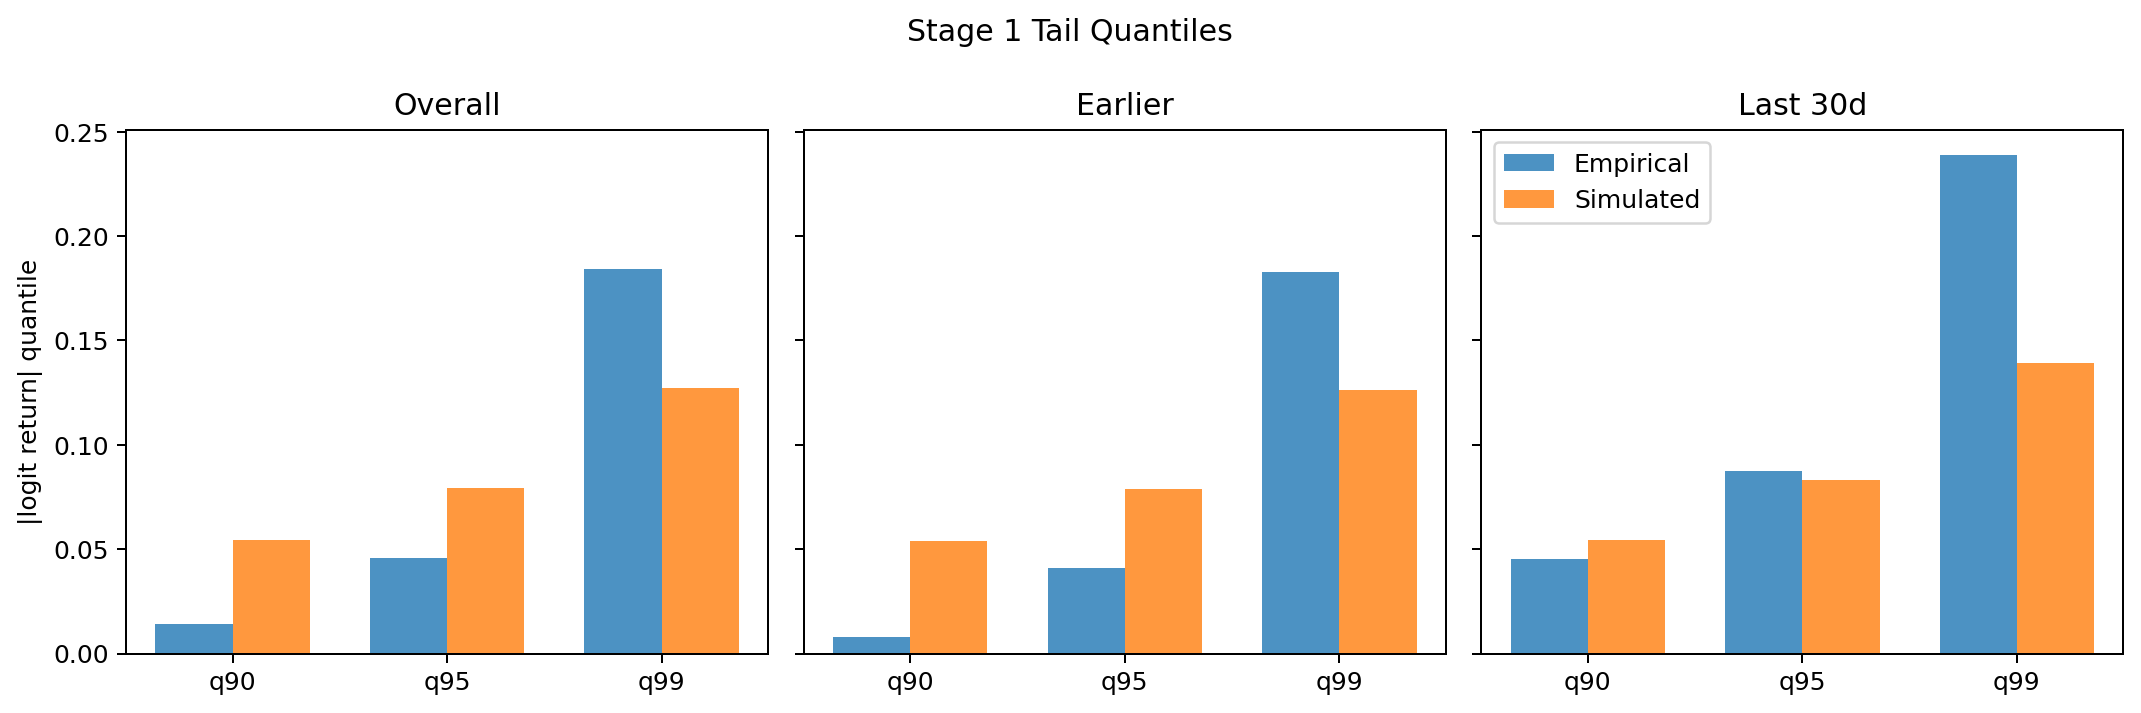

In [98]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_tail_quantiles.png'
if img.exists():
    display(Image(filename=str(img)))

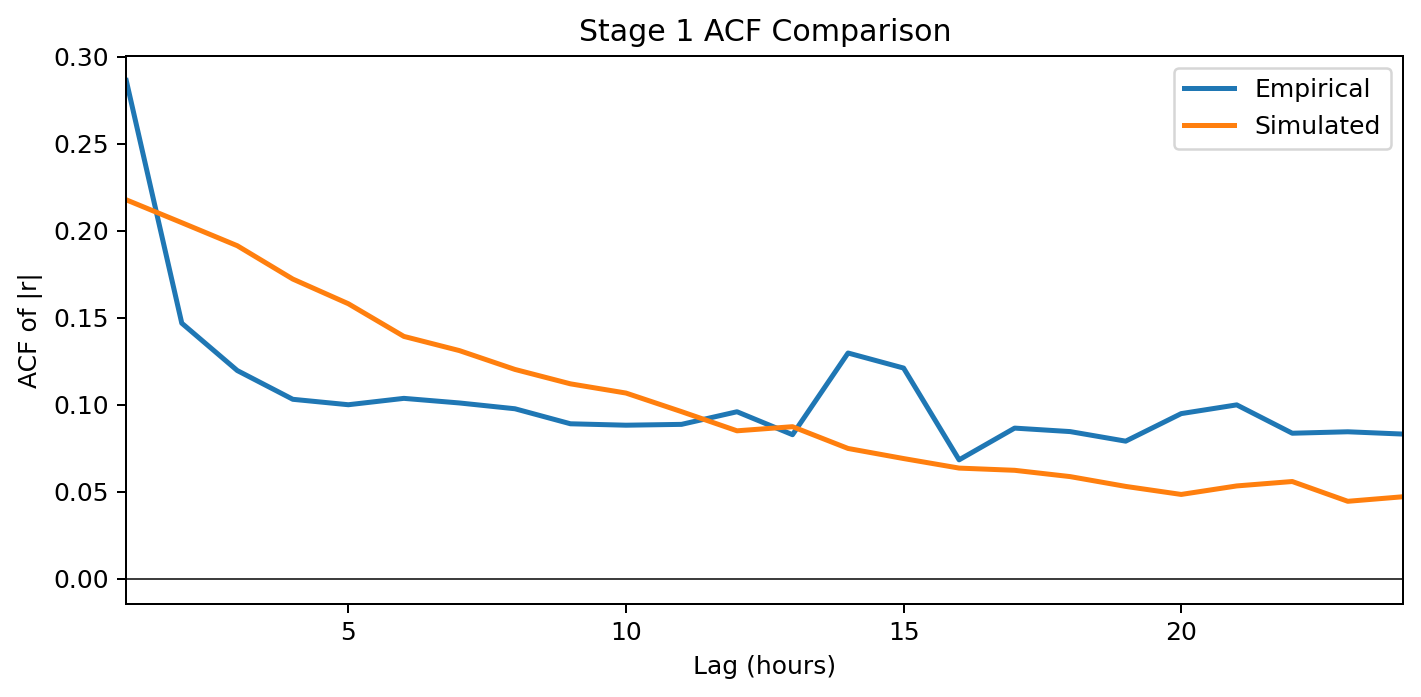

In [99]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_acf.png'
if img.exists():
    display(Image(filename=str(img)))

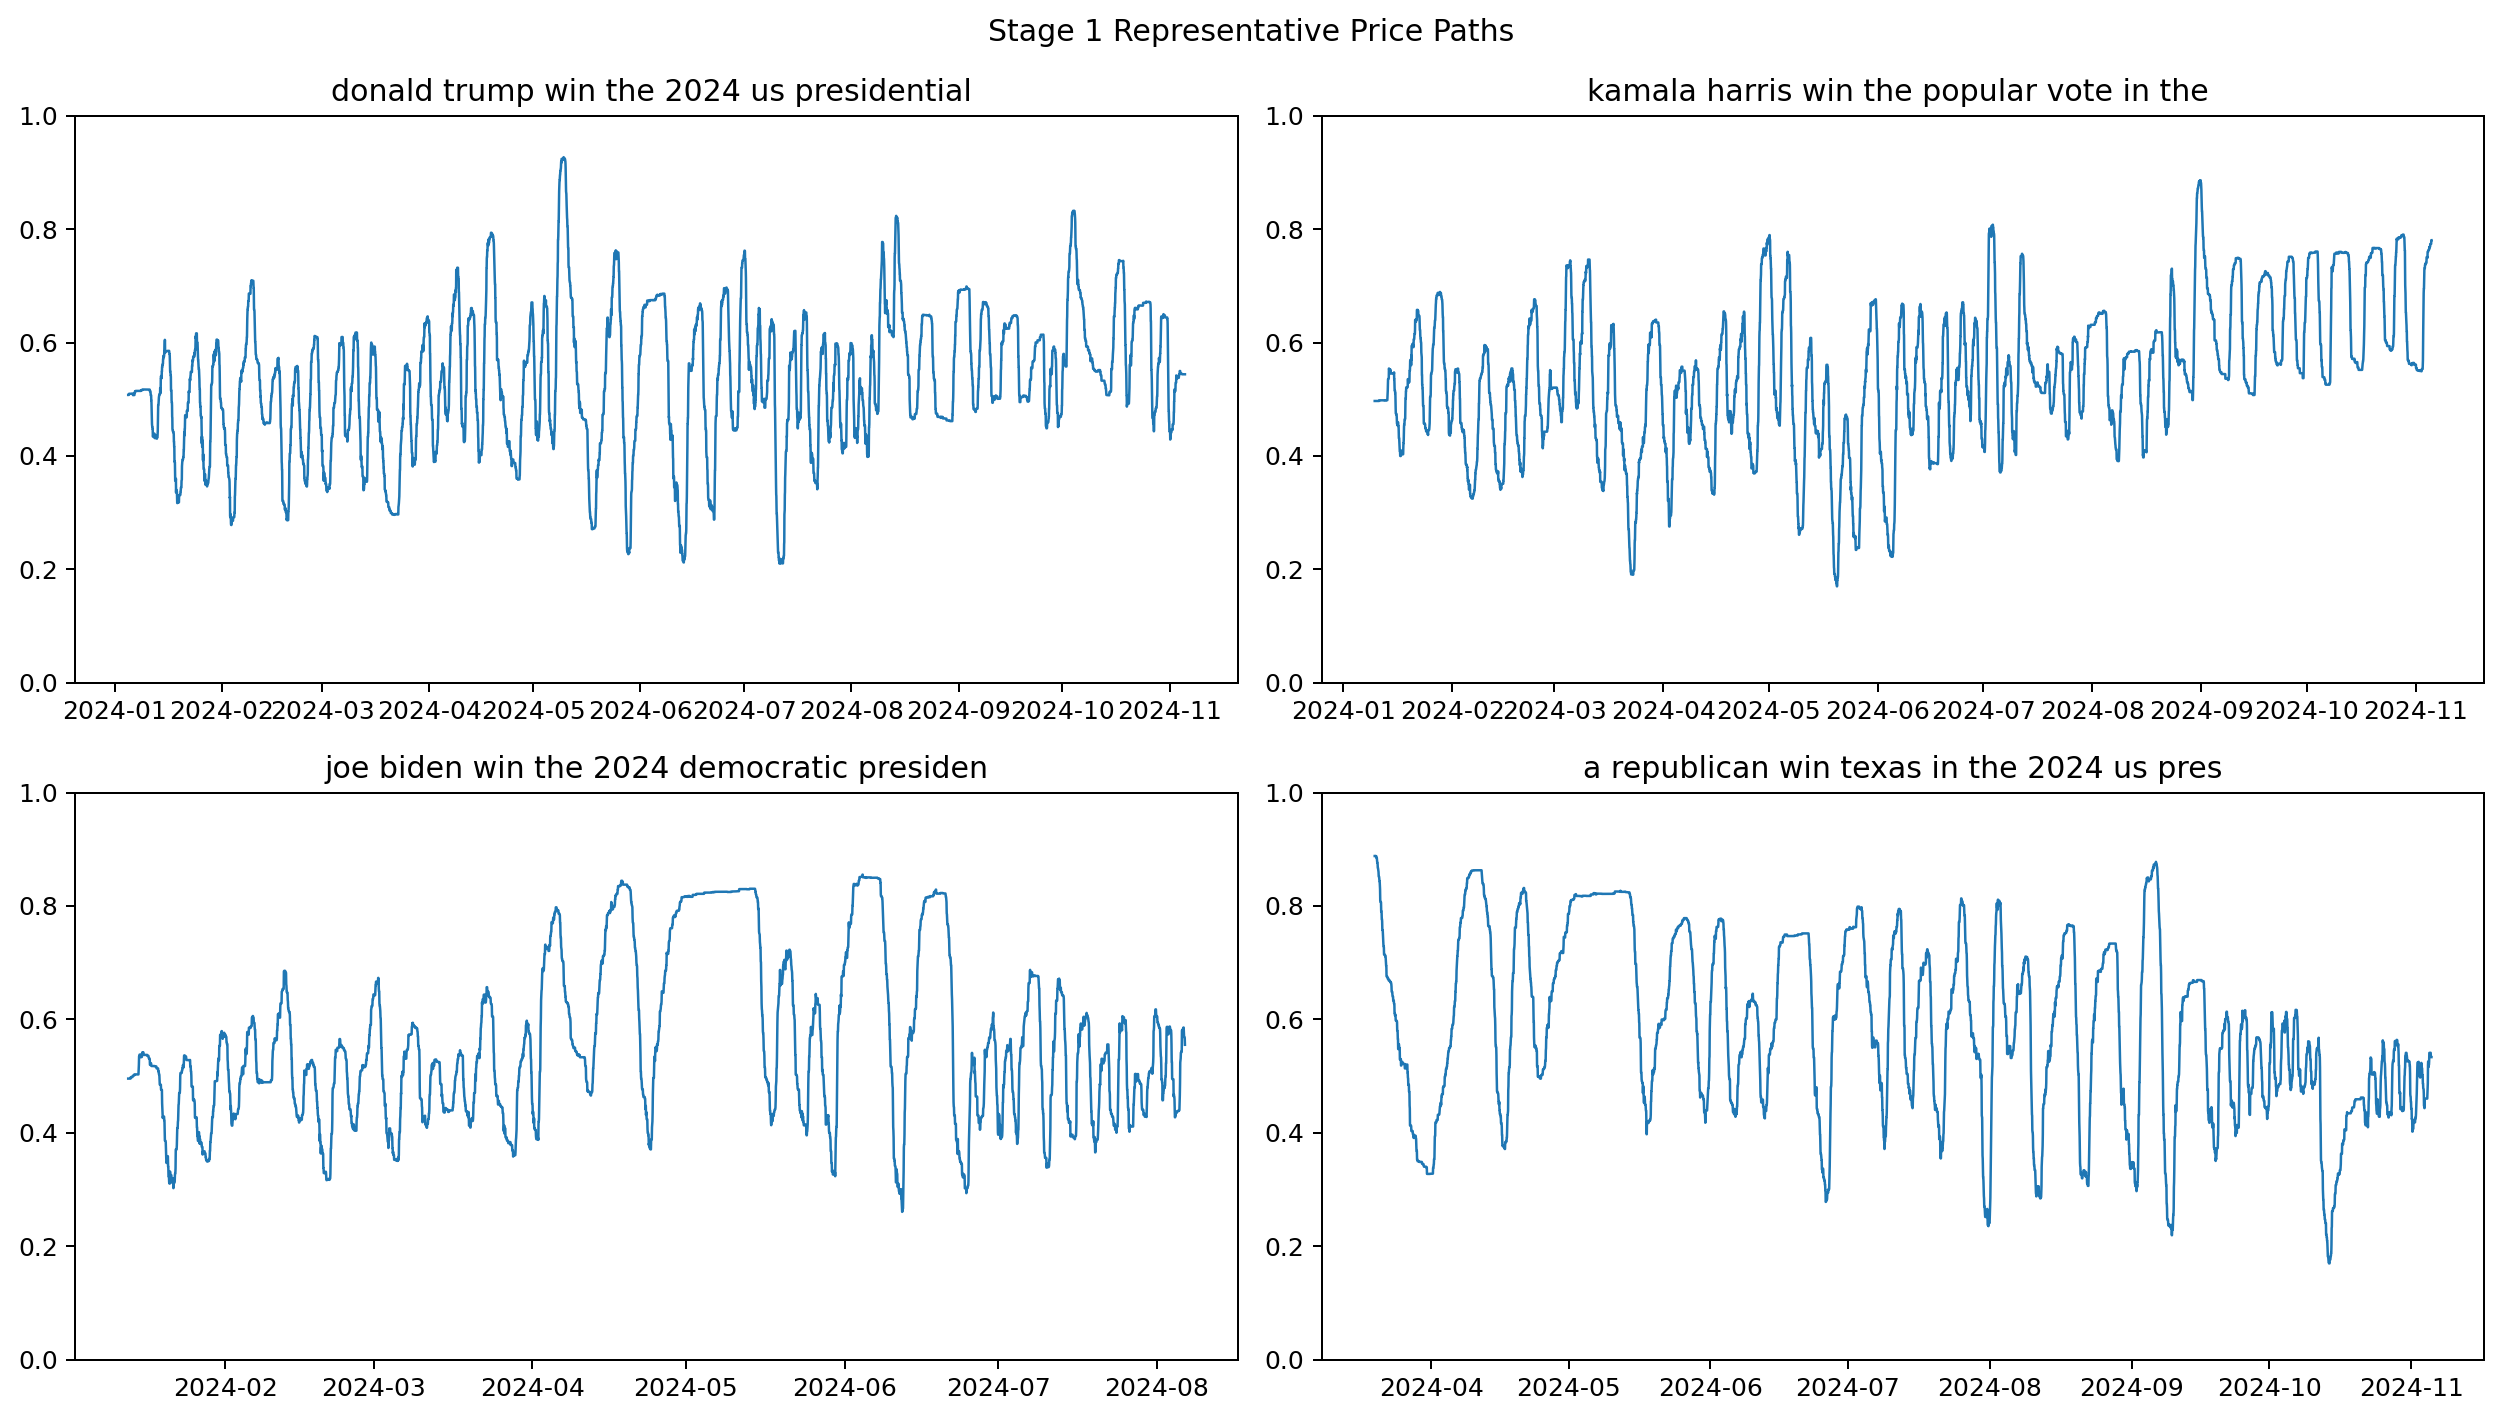

In [100]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_price_paths.png'
if img.exists():
    display(Image(filename=str(img)))

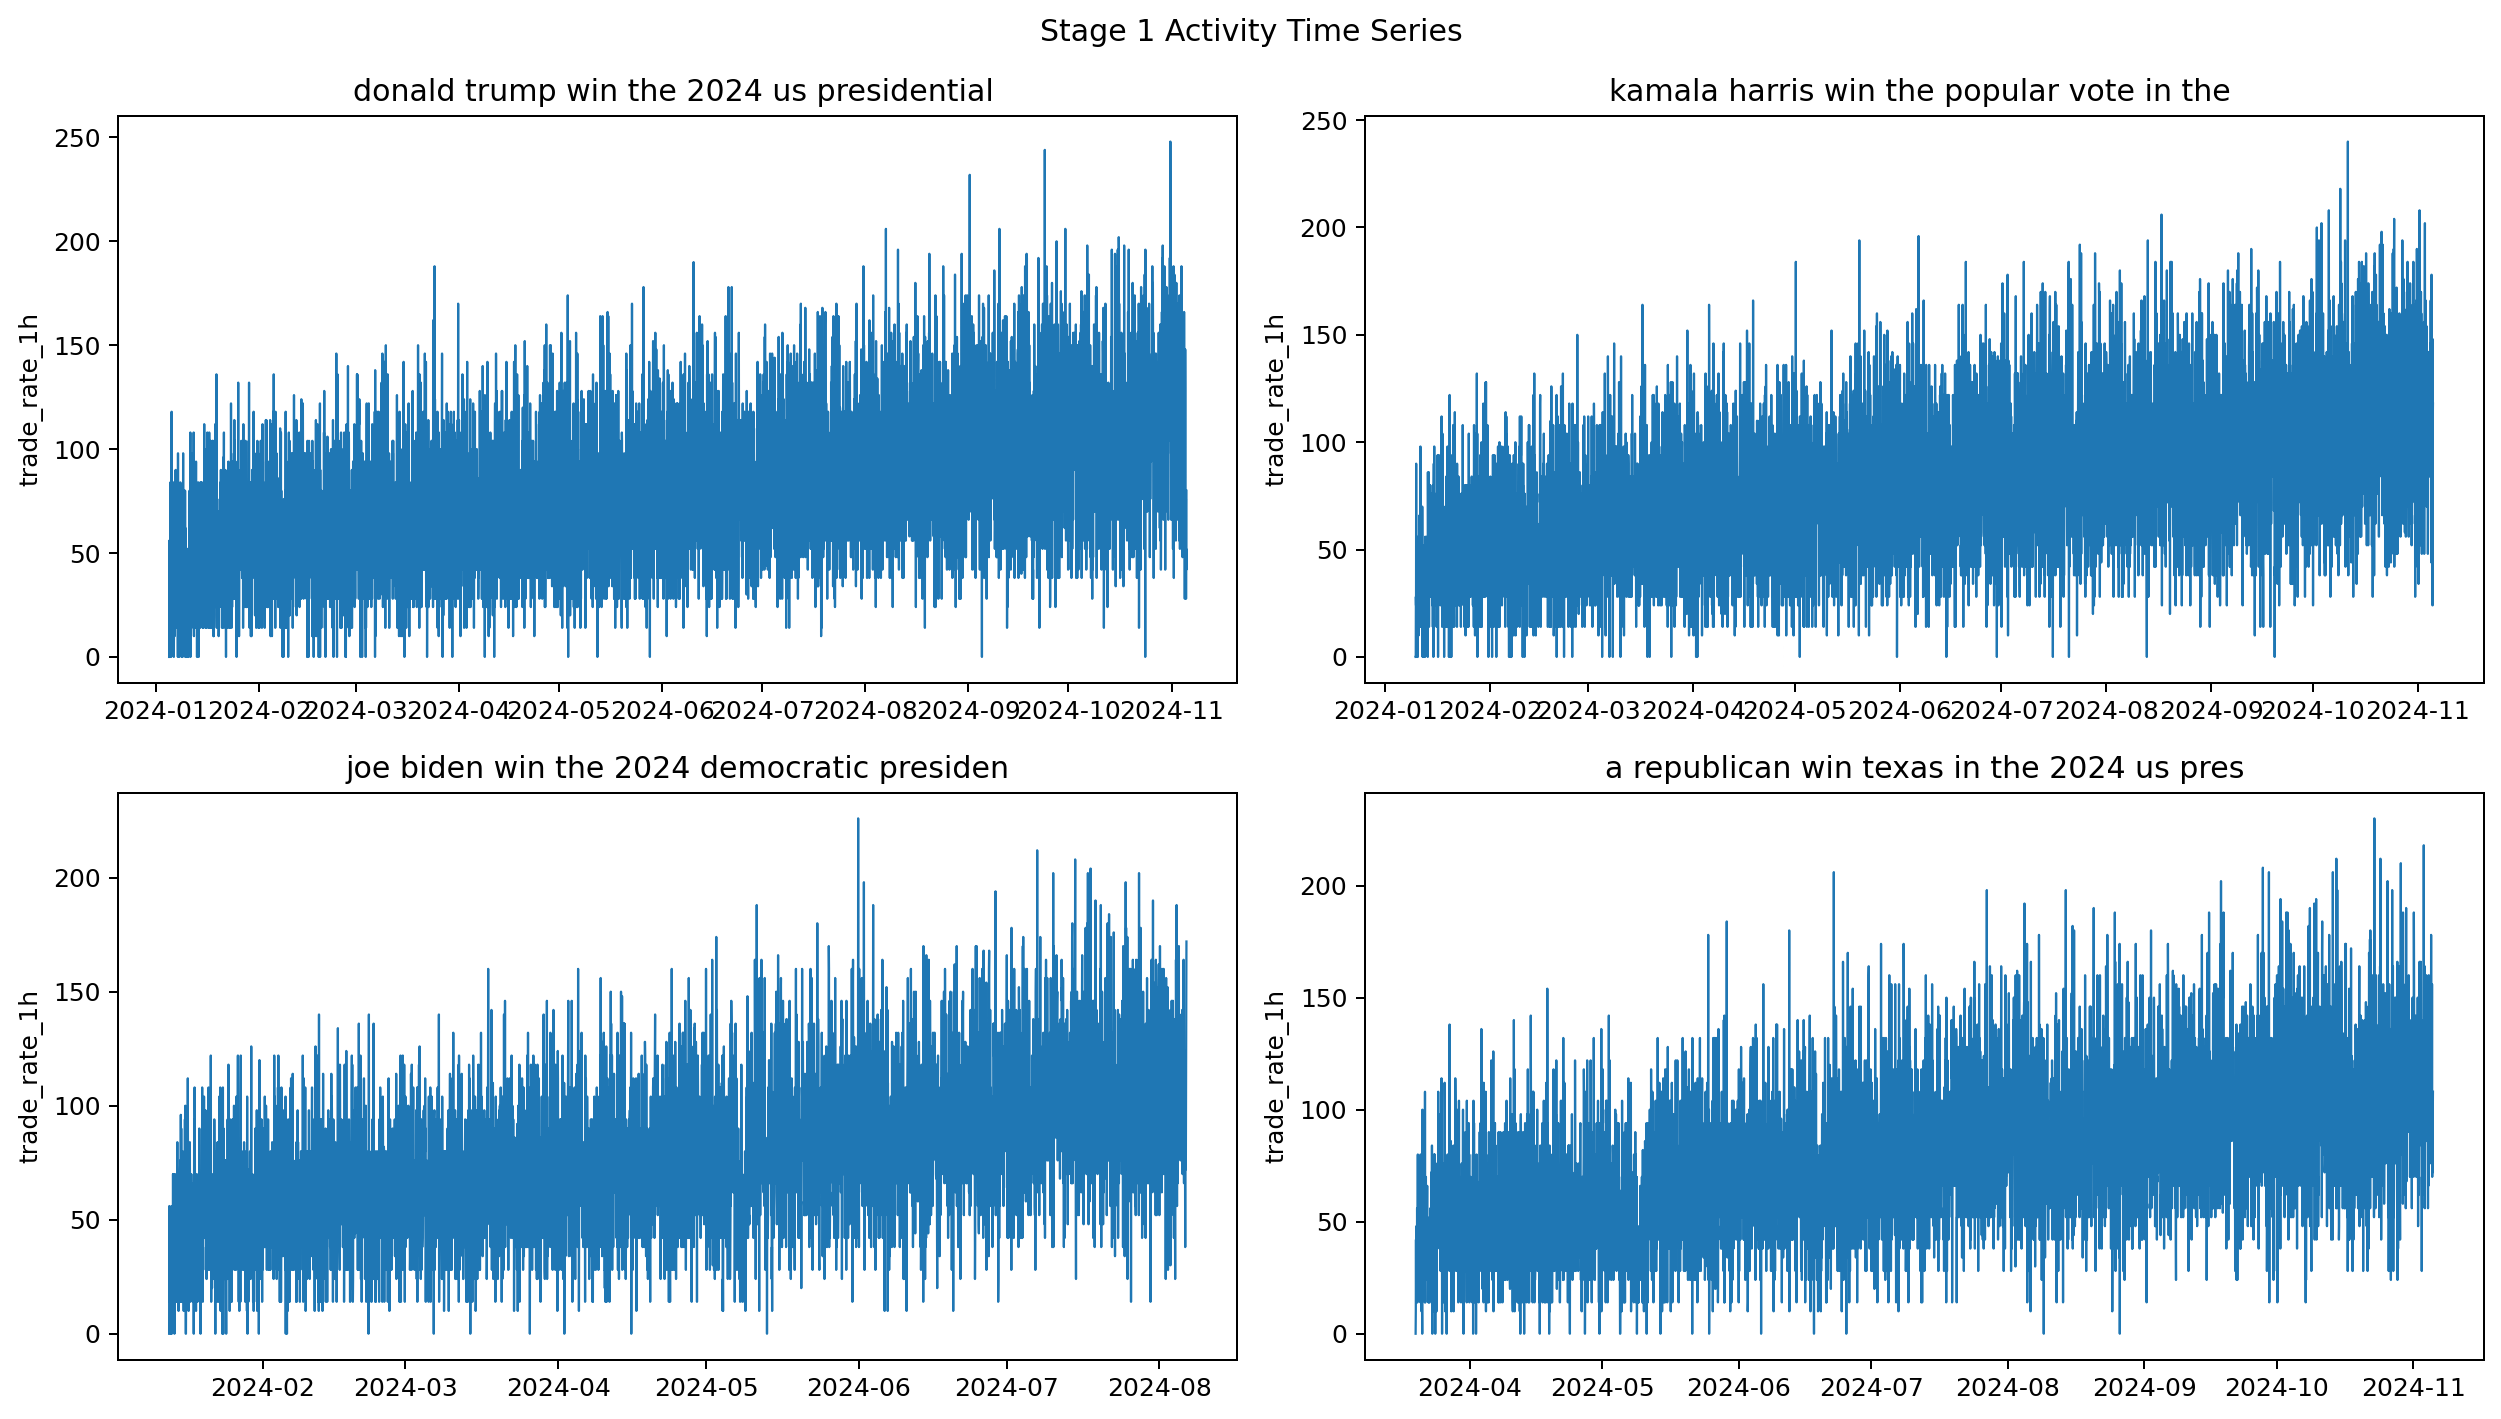

In [101]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_trade_rate.png'
if img.exists():
    display(Image(filename=str(img)))

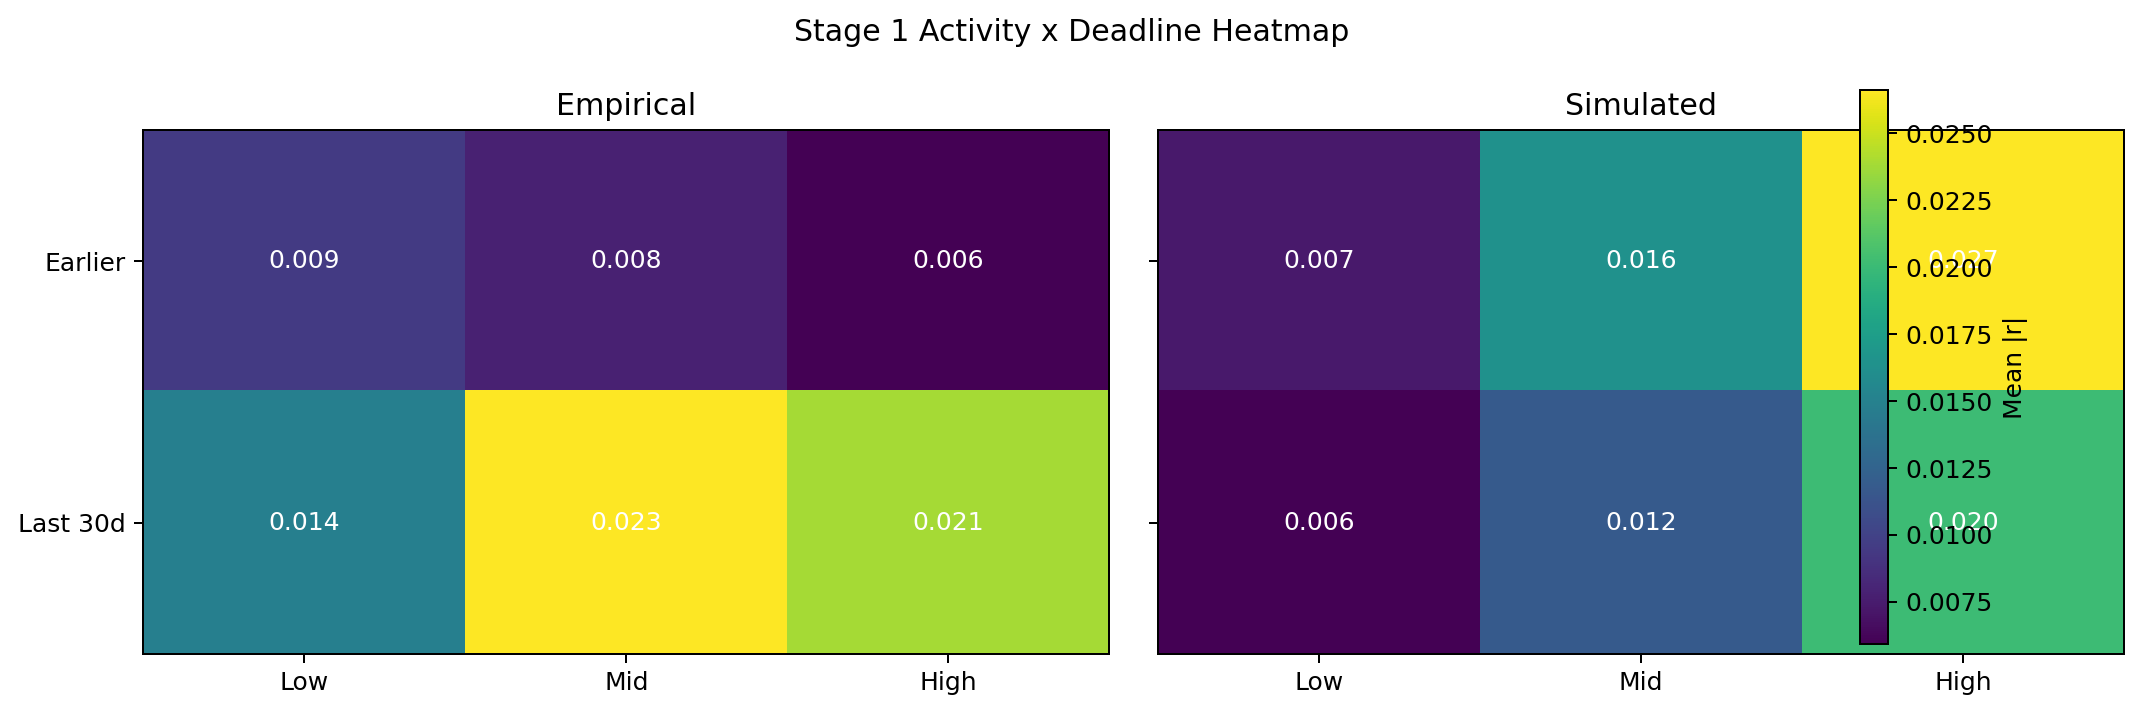

In [102]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_activity_heatmap.png'
if img.exists():
    display(Image(filename=str(img)))

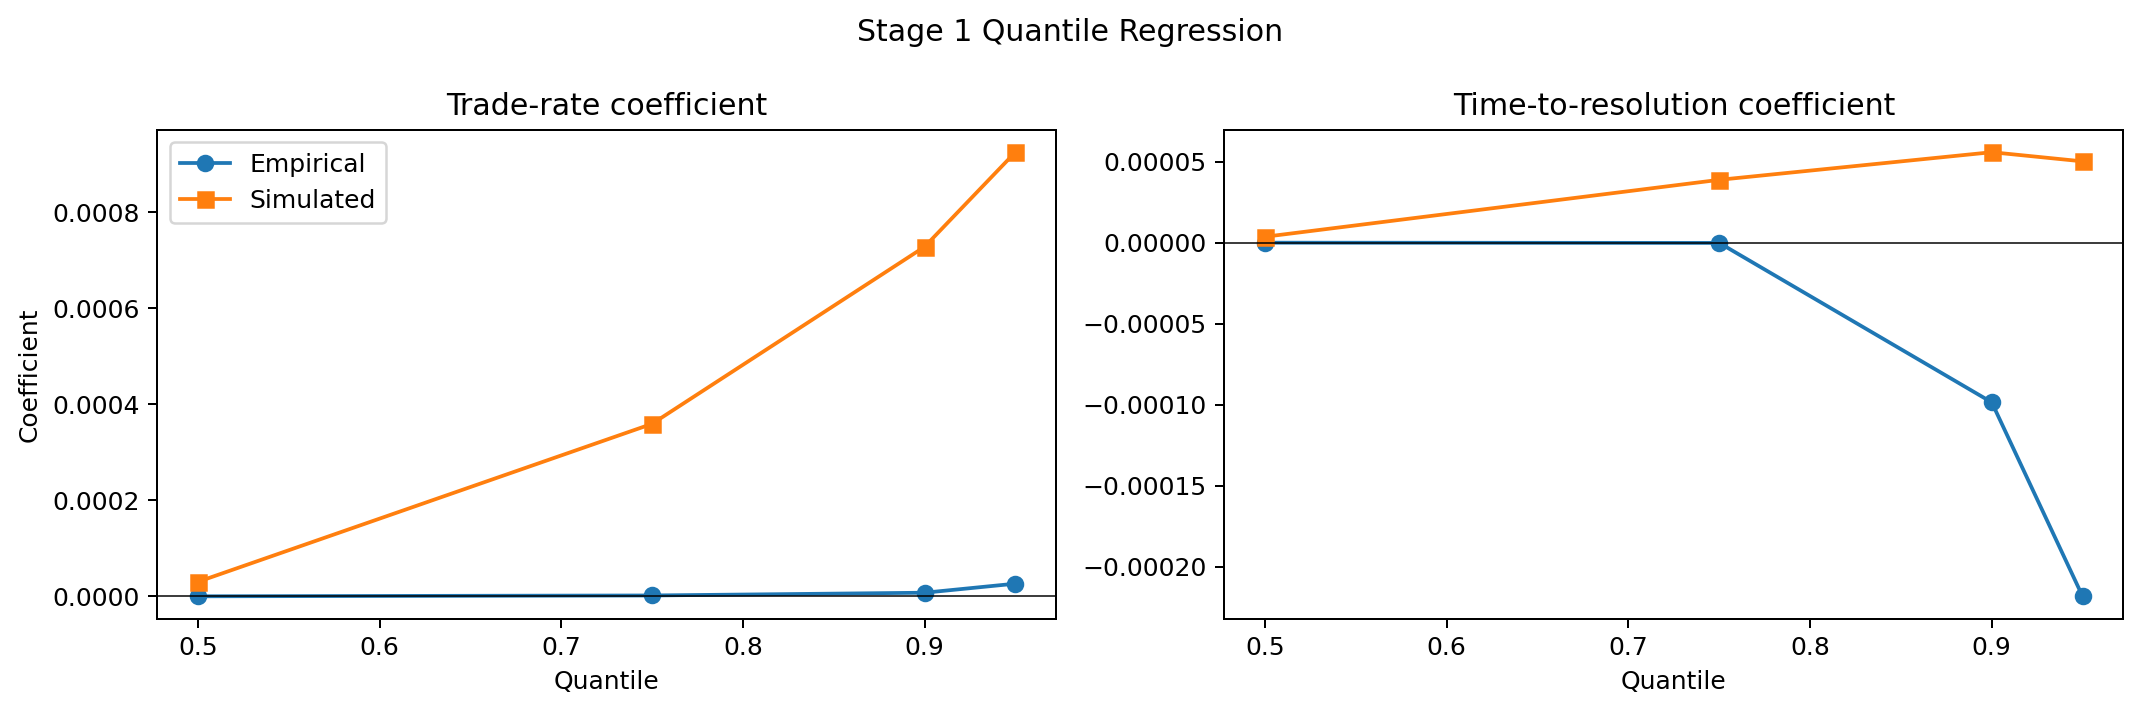

In [103]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_quantile_regression.png'
if img.exists():
    display(Image(filename=str(img)))

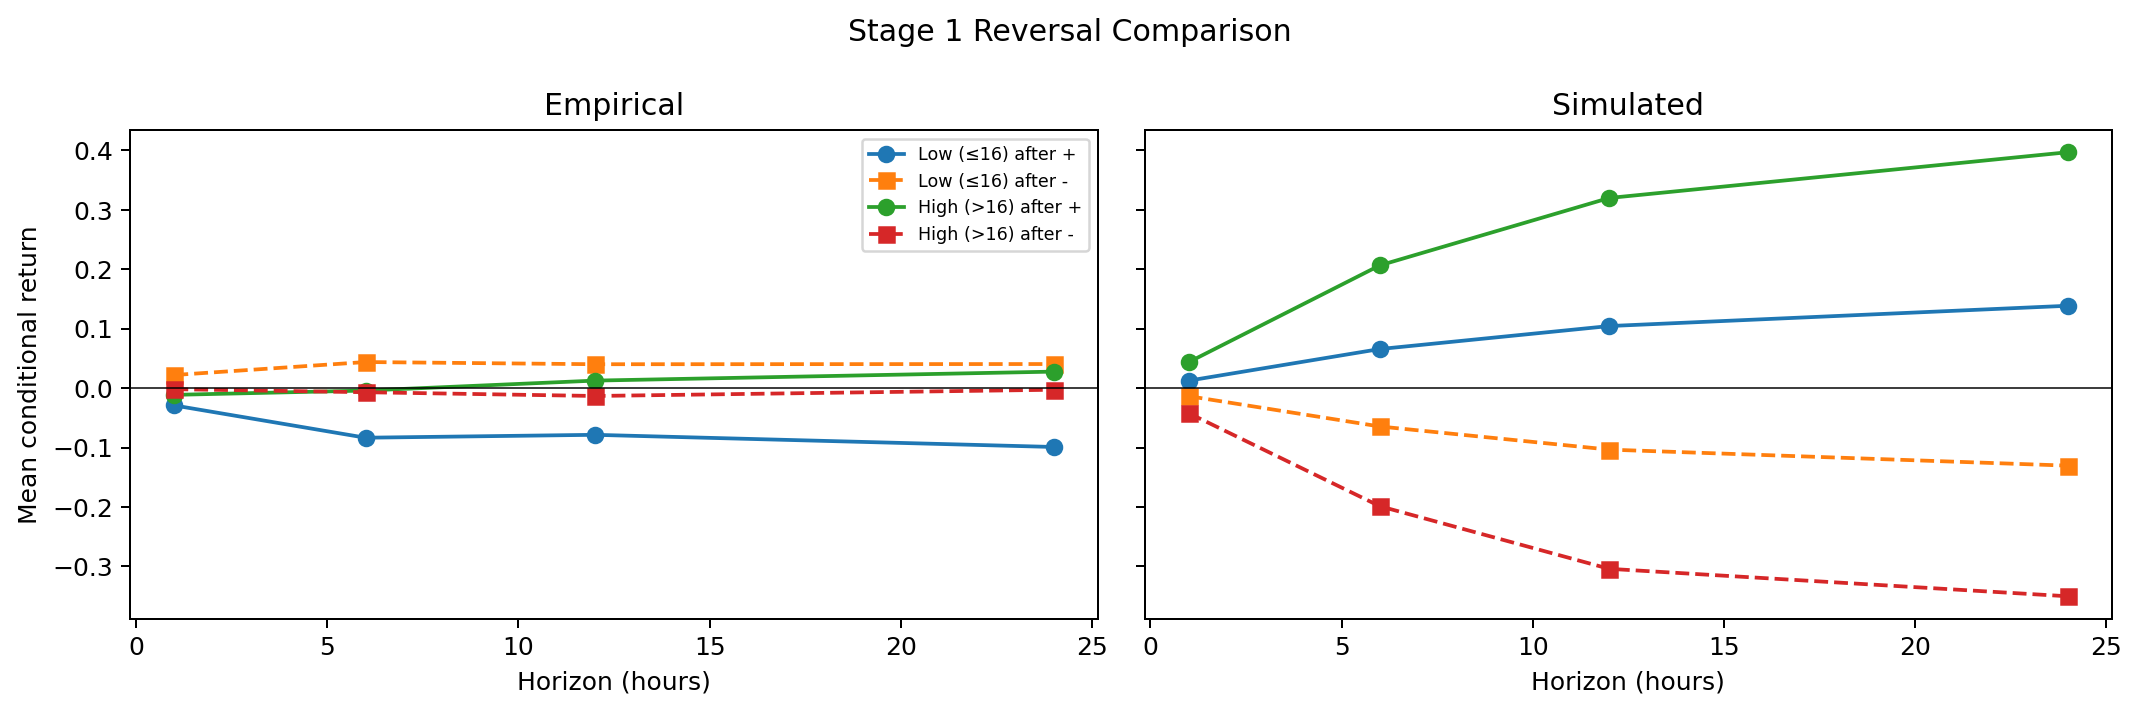

In [104]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_reversal_activity.png'
if img.exists():
    display(Image(filename=str(img)))

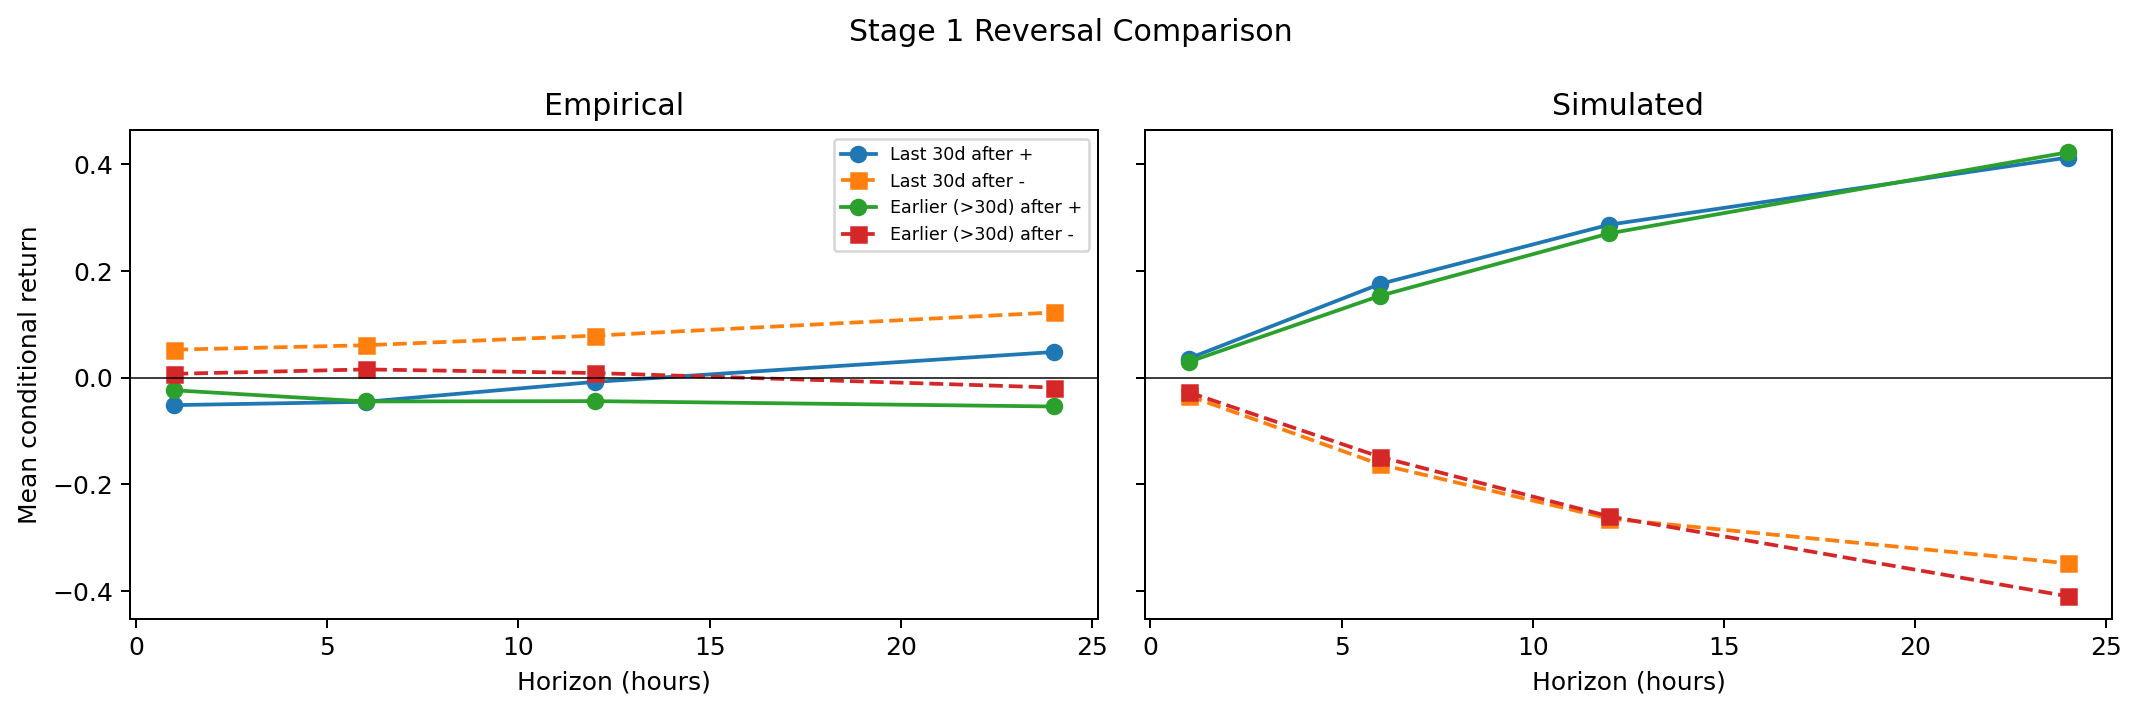

In [105]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage1_reversal_deadline.png'
if img.exists():
    display(Image(filename=str(img)))

## STAGE2

In [106]:
bundle = stage2
if bundle is None:
    display(Markdown('Stage 2 was not run.'))
else:
    display(Markdown(bundle['summary']))
    if bundle['tail_quantiles'] is not None:
        display(bundle['tail_quantiles'])
    if bundle['deadline_summary'] is not None:
        display(bundle['deadline_summary'])
    if bundle['interaction'] is not None:
        display(bundle['interaction'])
    if bundle['quantile_regression_raw'] is not None:
        display(bundle['quantile_regression_raw'])
    if bundle['final_seed_scores'] is not None:
        display(bundle['final_seed_scores'])


# STAGE2 Summary

## Mechanisms Present
- all stage-1 mechanisms
- participation responds to recent volatility and recent activity
- effective depth varies with activity, deadline pressure, and their interaction

## Empirical Targets Matched
- late life volatility
- quantile pattern

## Targets Still Missing or Weak
- heavy tails
- volatility clustering
- activity deadline pattern

## Calibration Snapshot
- total score: 0.7650
- tail error: 0.9486
- acf error: 1.0522
- deadline error: 0.3705
- ratio error: 0.0524
- monotonic penalty: 0.0000
- interaction error: 0.5931
- interaction pattern penalty: 0.3333
- quantile error: 2.0230

## Next Stage Decision
- justified: yes
- reason: Stage 3 is justified because low-activity reversal remains weaker than the empirical asymmetry.

,q90,q95,q99,mean_abs_r,std_r
period,,,,,
Overall,0.041391,0.066288,0.131852,0.012332,0.030418
Earlier,0.037564,0.059539,0.110888,0.010822,0.025738
Last 30d,0.080278,0.127790,0.221279,0.023842,0.054116


,n,mean_abs_r,std_r,kurtosis,skewness,acf1_abs_r,mean_trade_rate
period,,,,,,,
Earlier,78720,0.010822,0.025738,15.071533,0.022209,0.356121,91.516092
Last 30d,10327,0.023842,0.054116,13.231735,-0.218899,0.416577,123.172040


mean_abs_r     std_r      n
ttr_phase activity_bin                             
Earlier   Low             0.004467  0.013335  28658
          Mid             0.010827  0.023802  26663
          High            0.018599  0.036951  23399
Last 30d  Low             0.006957  0.020150   1178
          Mid             0.015105  0.036371   3117
          High            0.031654  0.065201   6032

,trade_rate_coef,trade_rate_p,ttr_coef,ttr_p,pseudo_r2
quantile,,,,,
0.50,0.000006,0.0,-4.282011e-08,4.095802e-01,0.000527
0.75,0.000175,0.0,-2.073550e-05,6.255133e-95,0.070481
0.90,0.000376,0.0,-8.733371e-05,5.288325e-286,0.136339
0.95,0.000490,0.0,-1.424141e-04,1.780786e-309,0.182717


,seed,score,tail_error,acf_error,deadline_error,ratio_error,monotonic_penalty,total_score,interaction_error,interaction_pattern_penalty,quantile_error
0,401,0.773225,1.002382,0.995864,0.373804,0.039834,0.0,0.773225,0.608329,0.333333,2.043305
1,402,0.765029,0.948642,1.052226,0.370450,0.052441,0.0,0.765029,0.593118,0.333333,2.022998


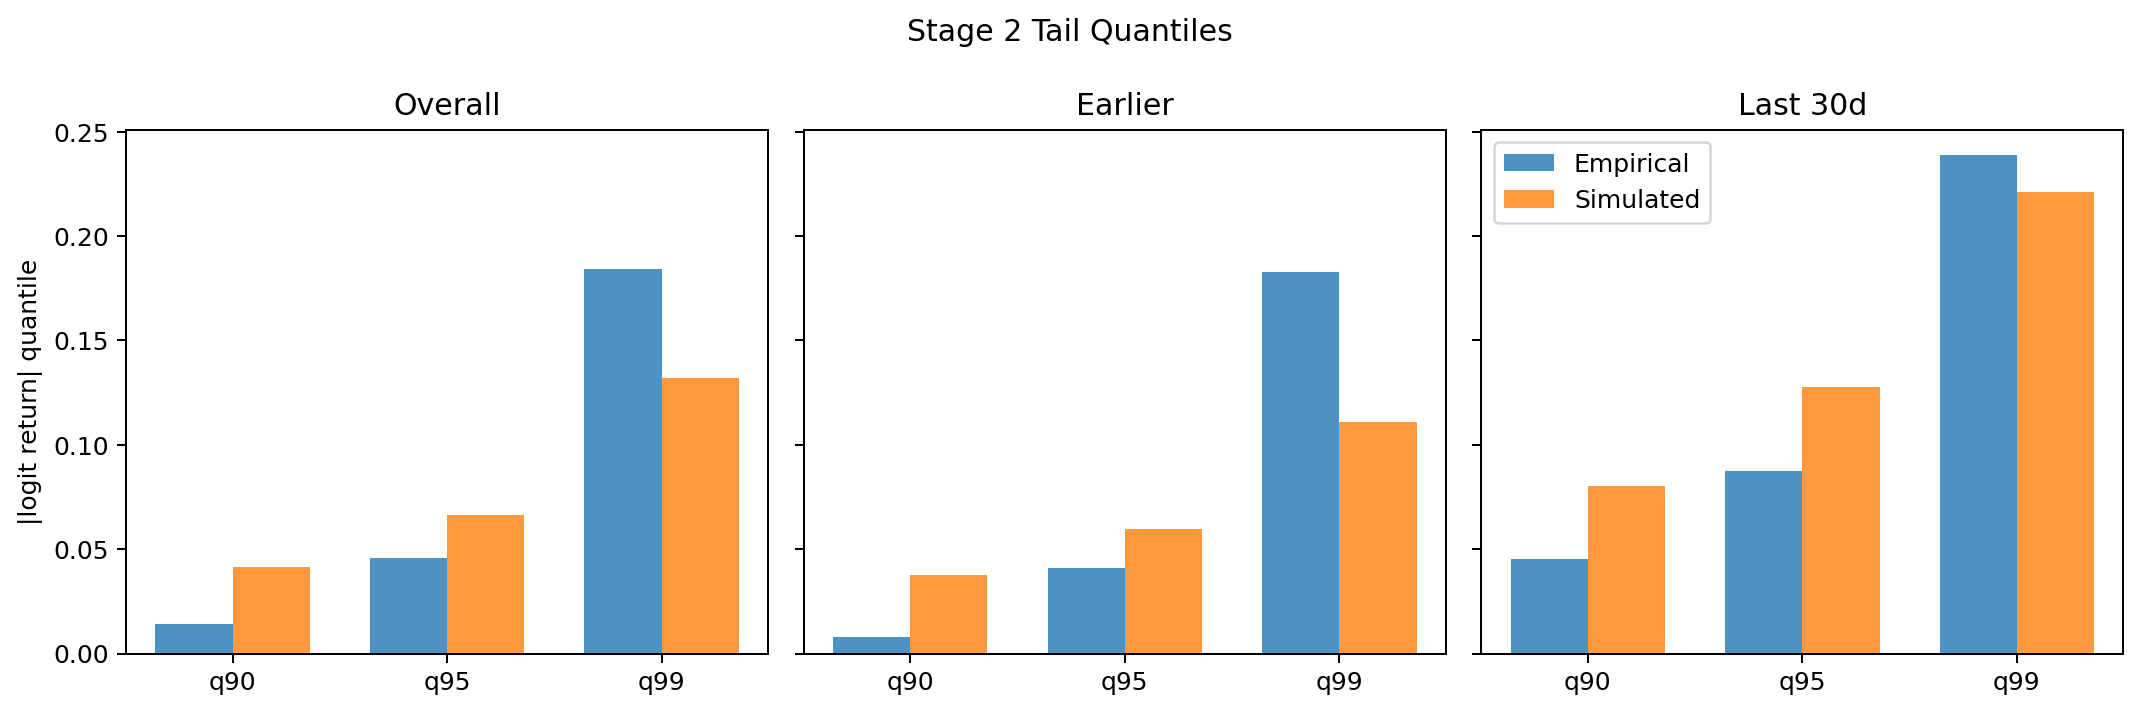

In [107]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_tail_quantiles.png'
if img.exists():
    display(Image(filename=str(img)))

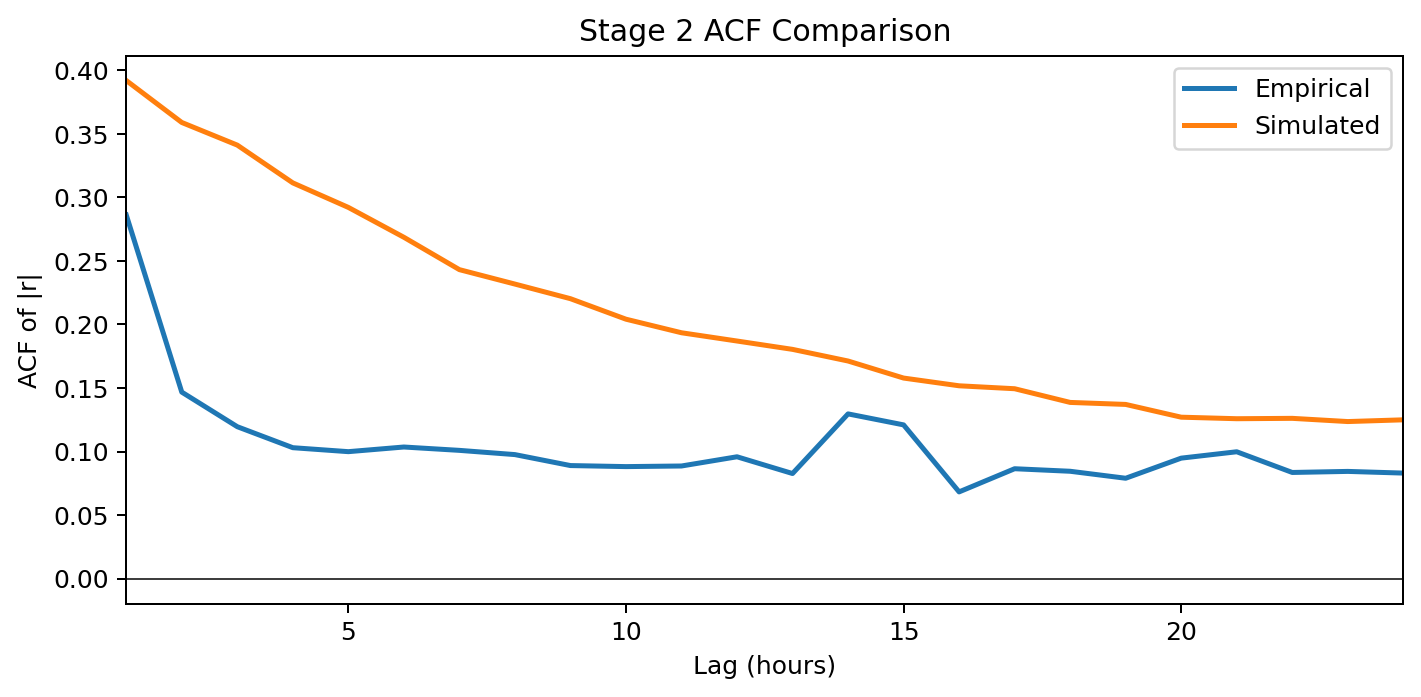

In [108]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_acf.png'
if img.exists():
    display(Image(filename=str(img)))

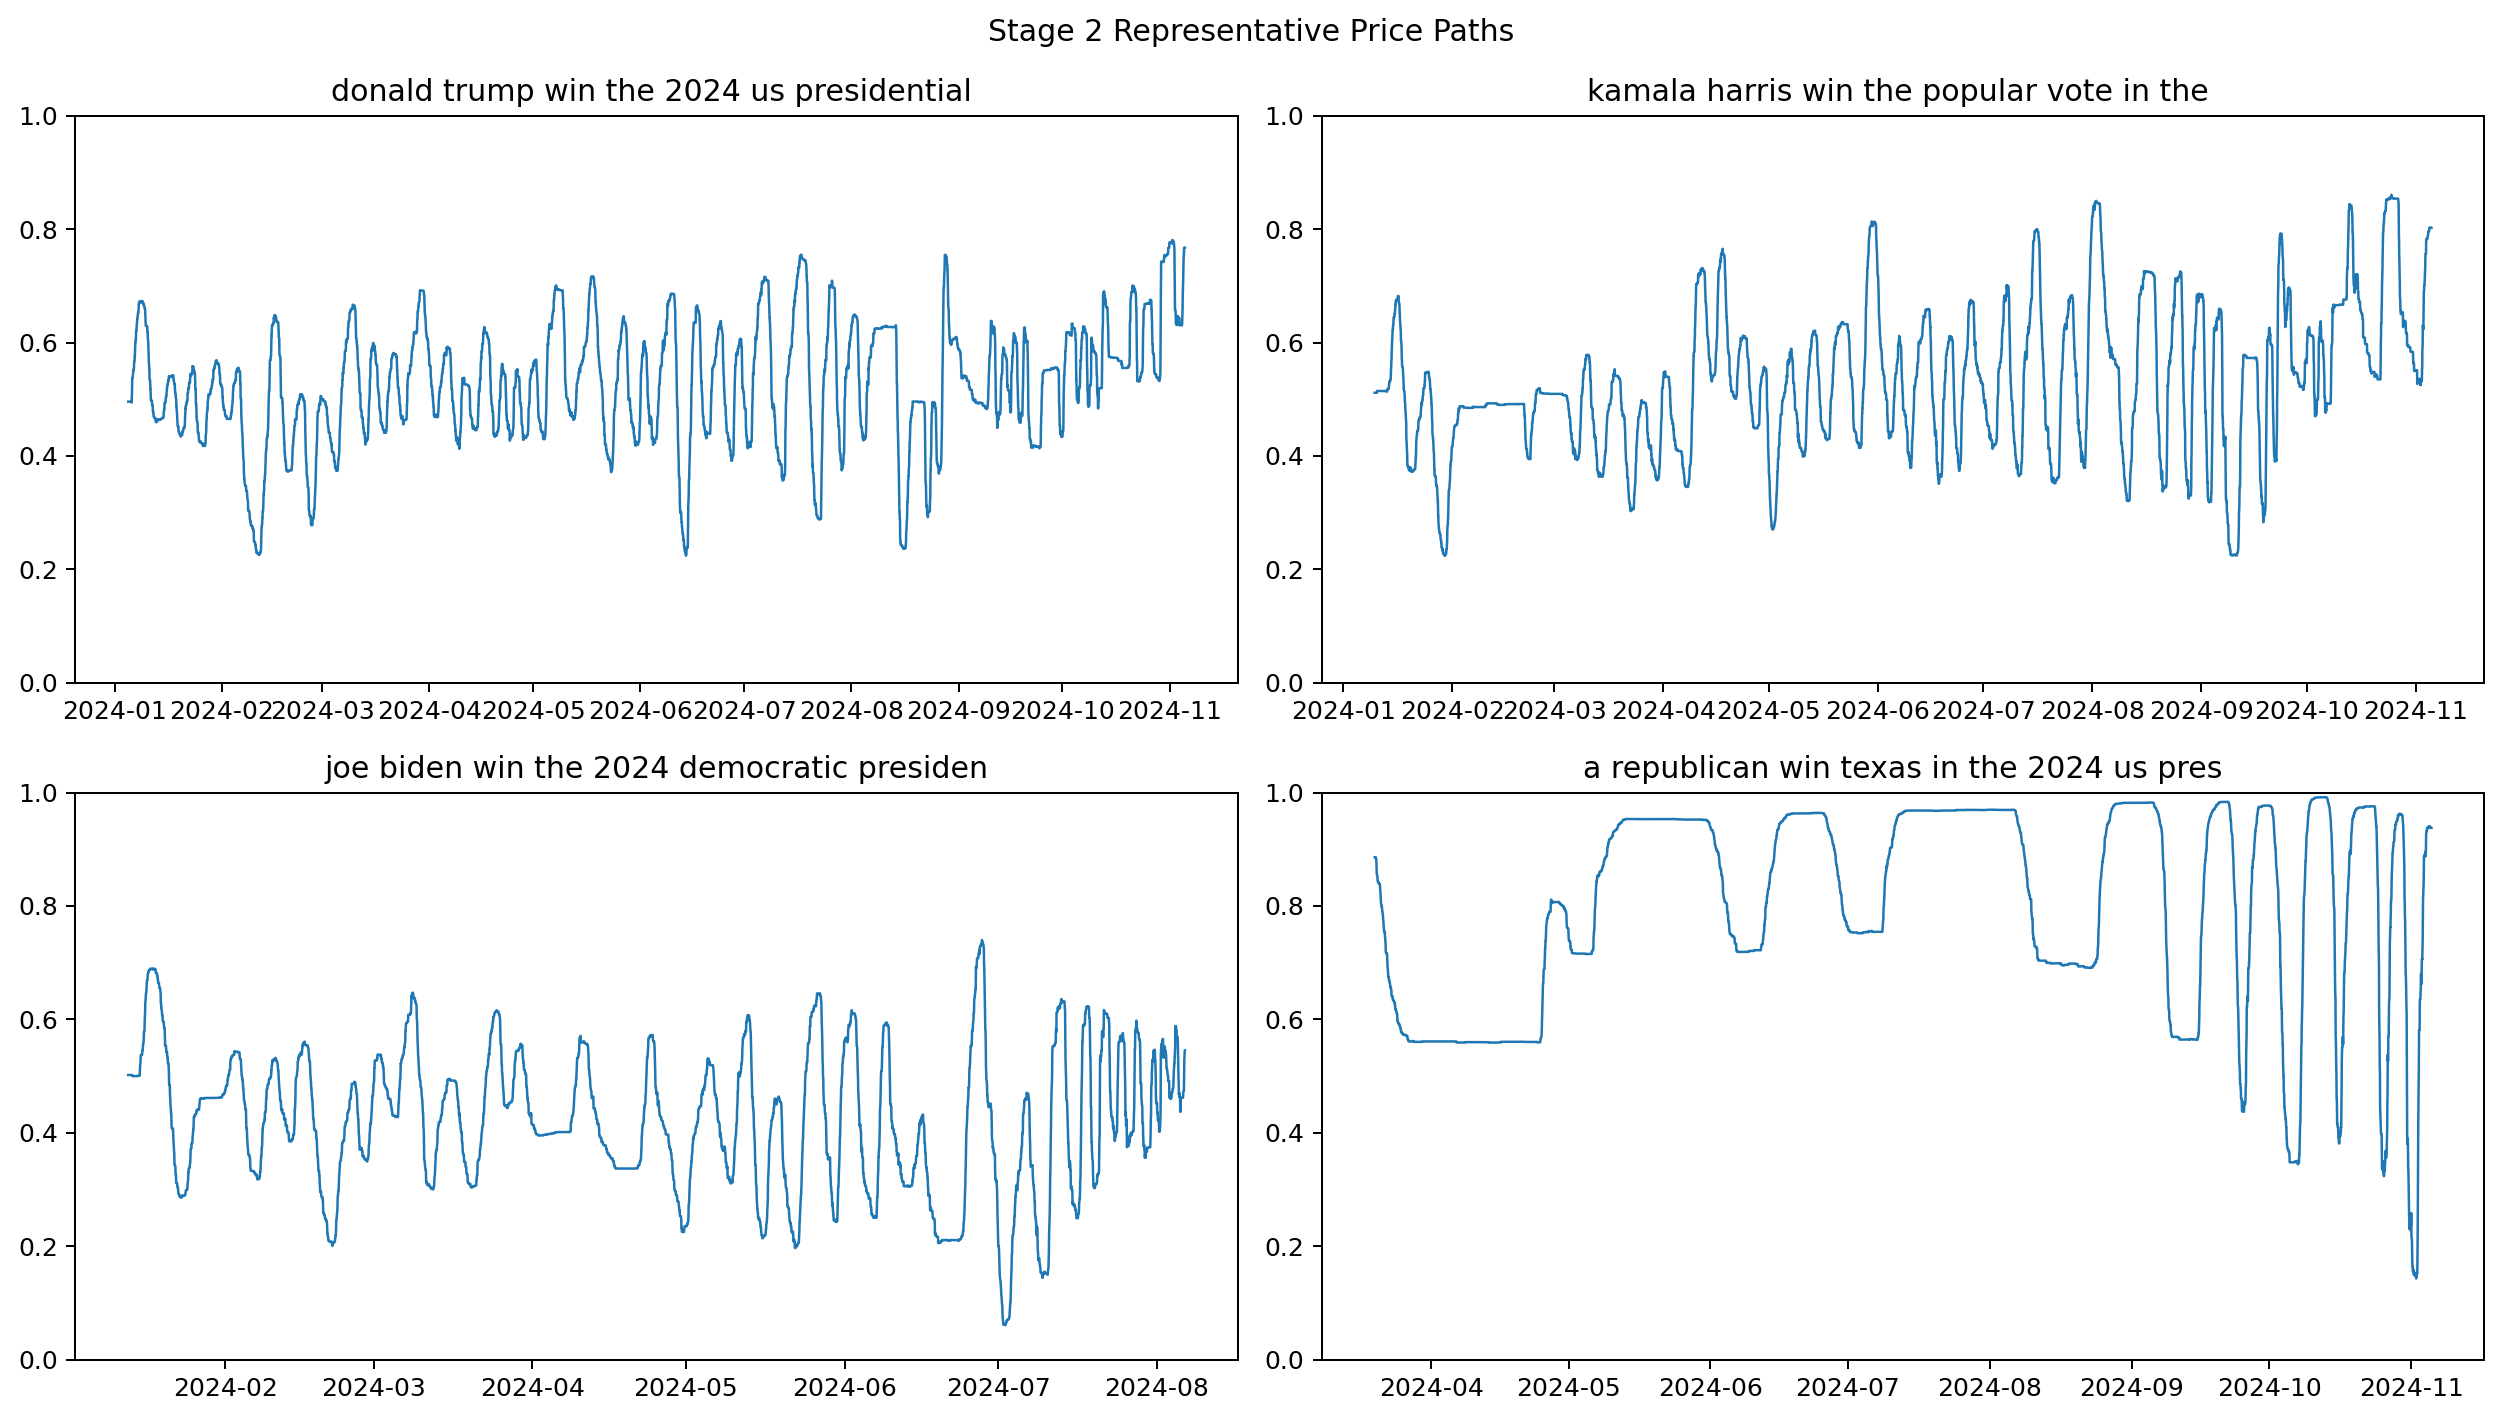

In [109]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_price_paths.png'
if img.exists():
    display(Image(filename=str(img)))

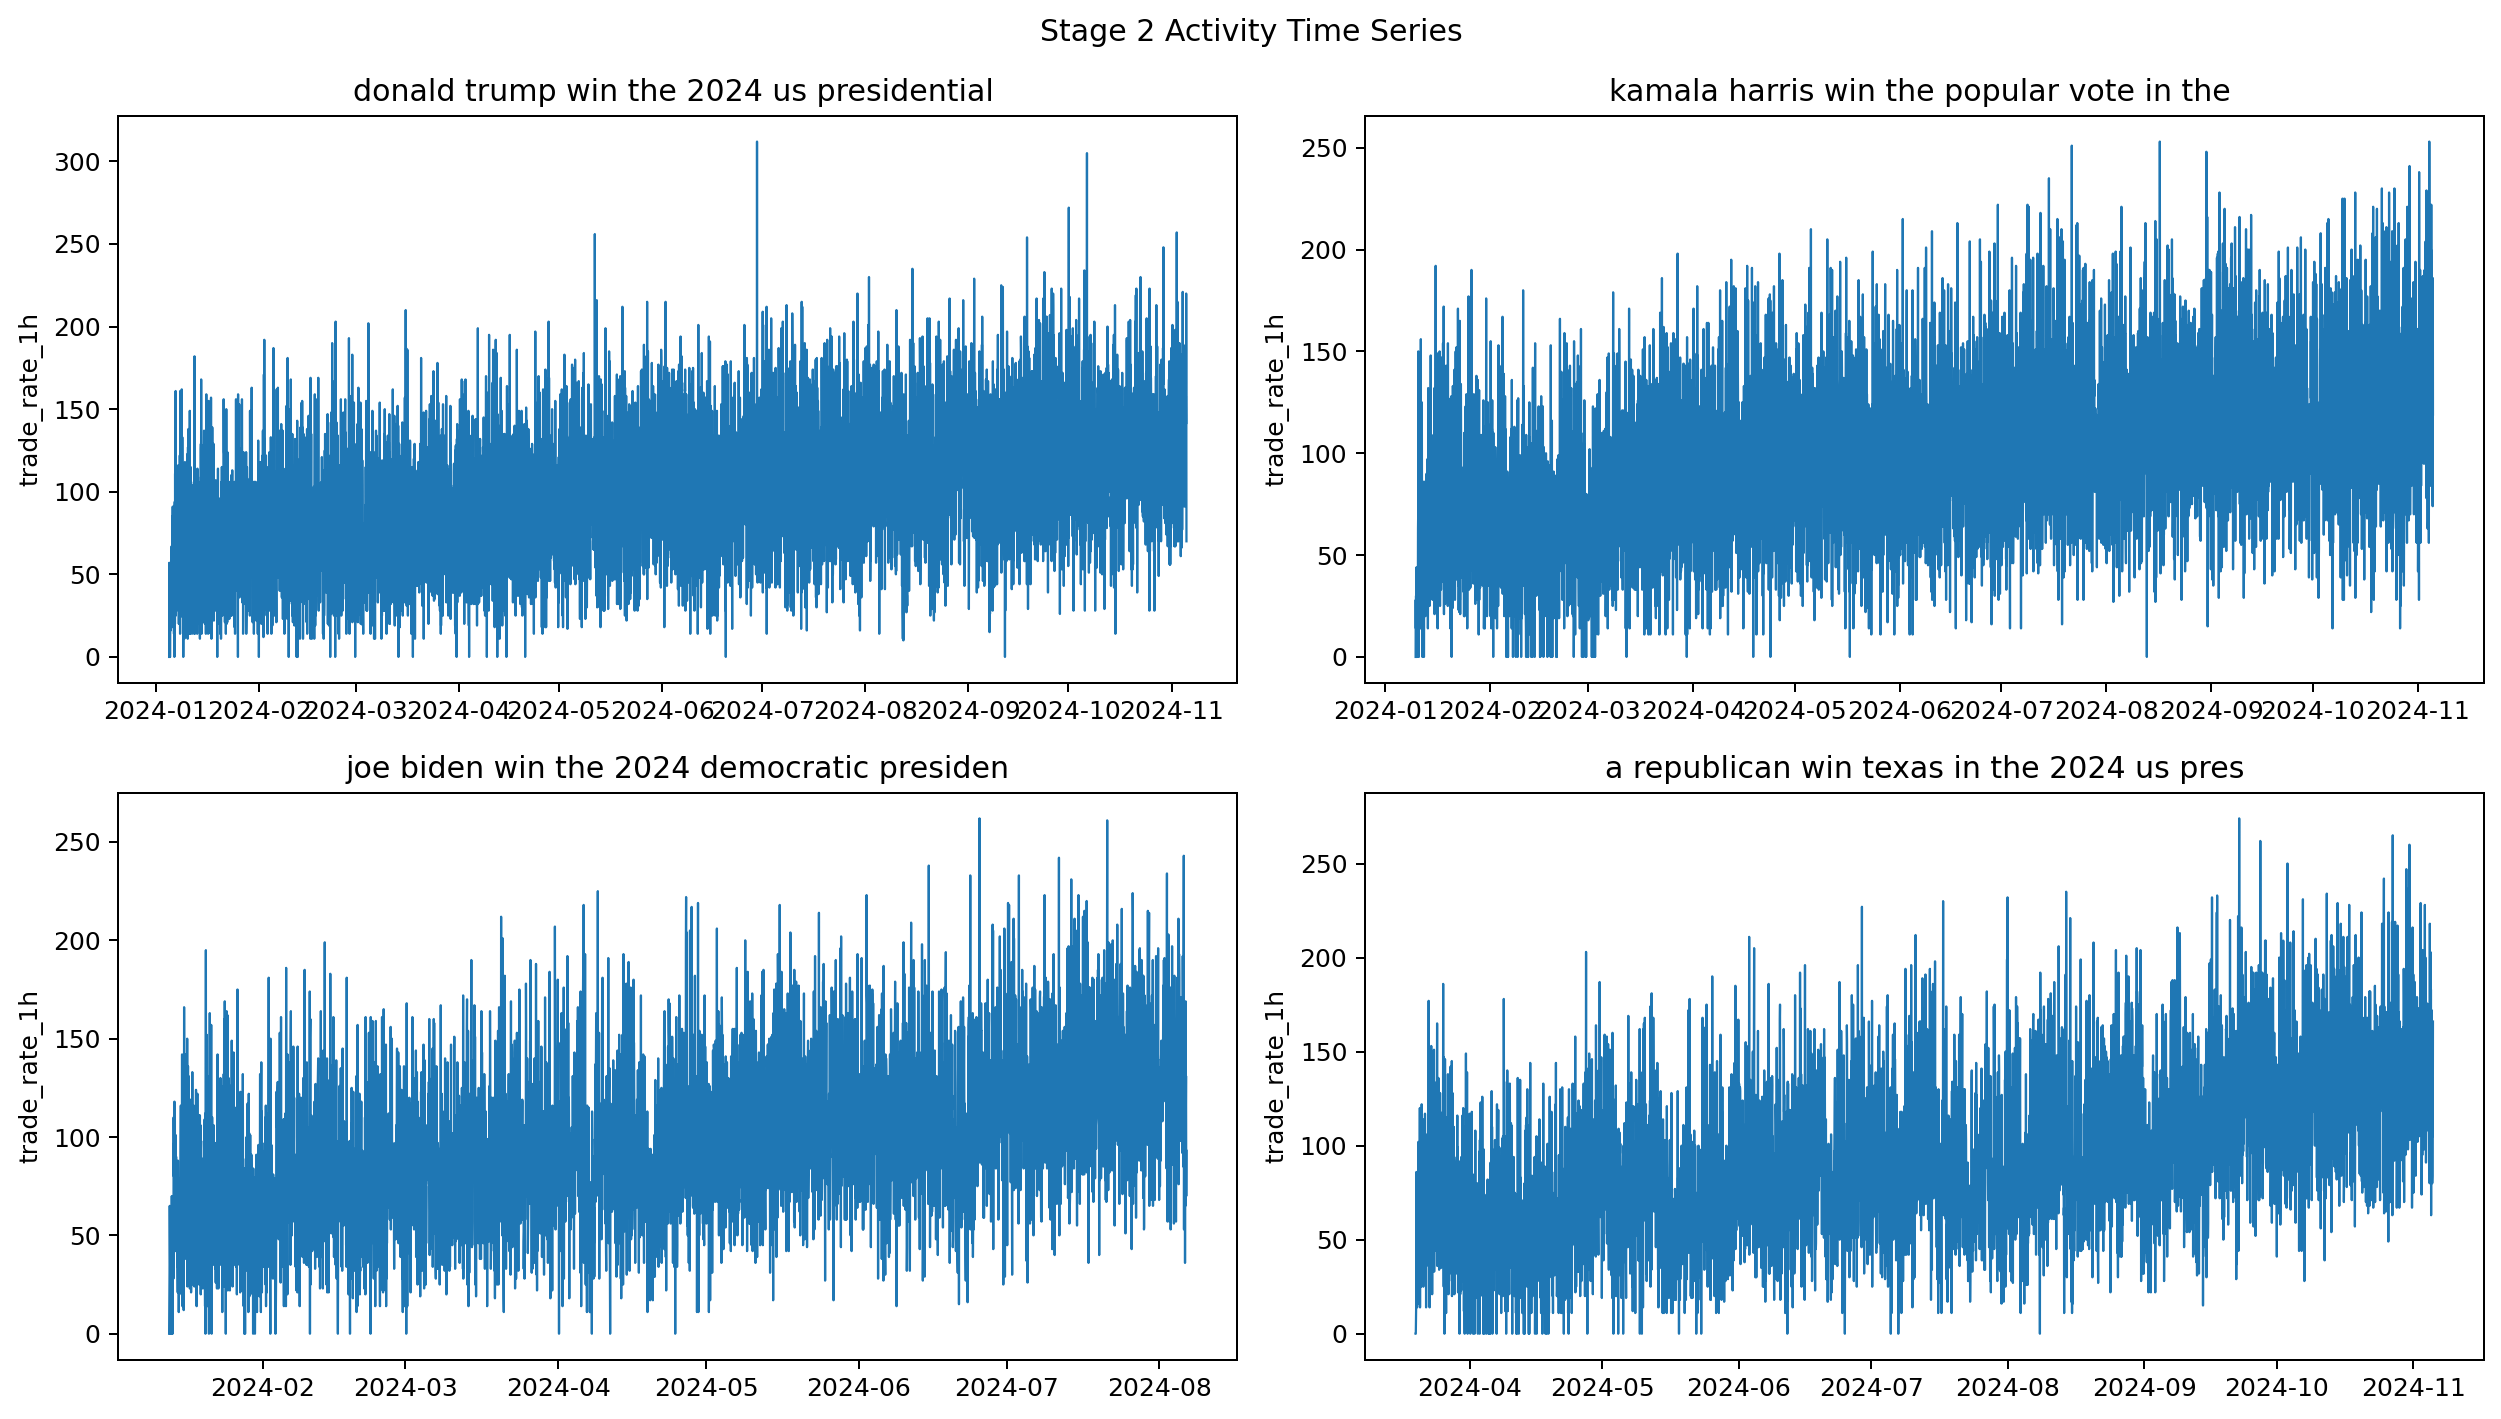

In [110]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_trade_rate.png'
if img.exists():
    display(Image(filename=str(img)))

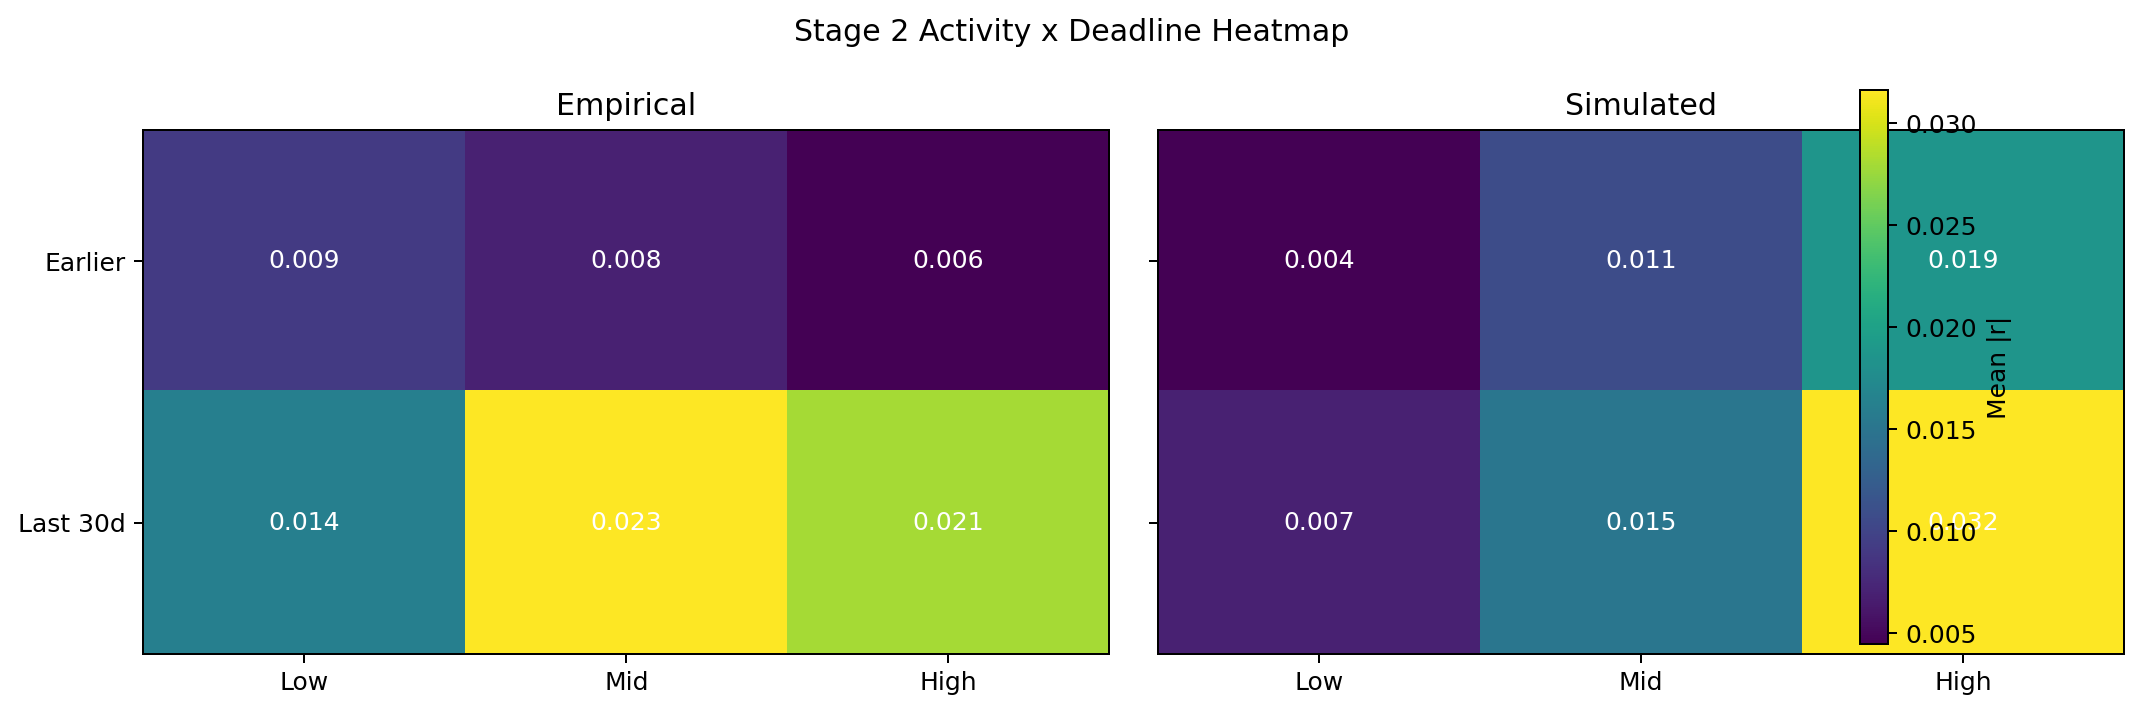

In [111]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_activity_heatmap.png'
if img.exists():
    display(Image(filename=str(img)))

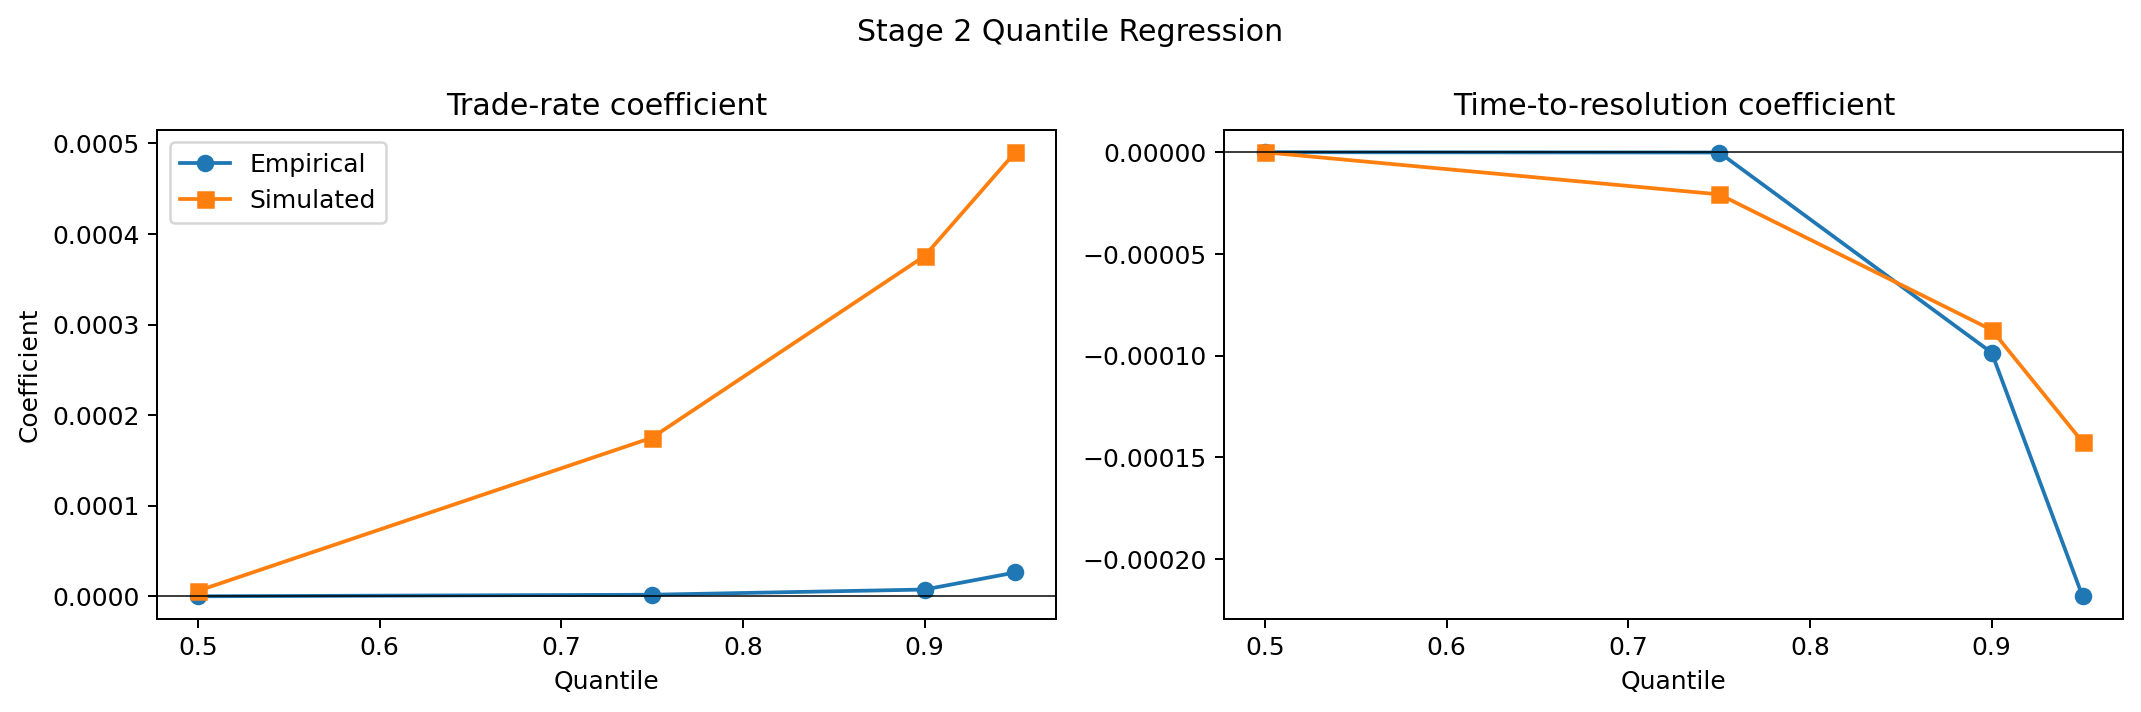

In [112]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_quantile_regression.png'
if img.exists():
    display(Image(filename=str(img)))

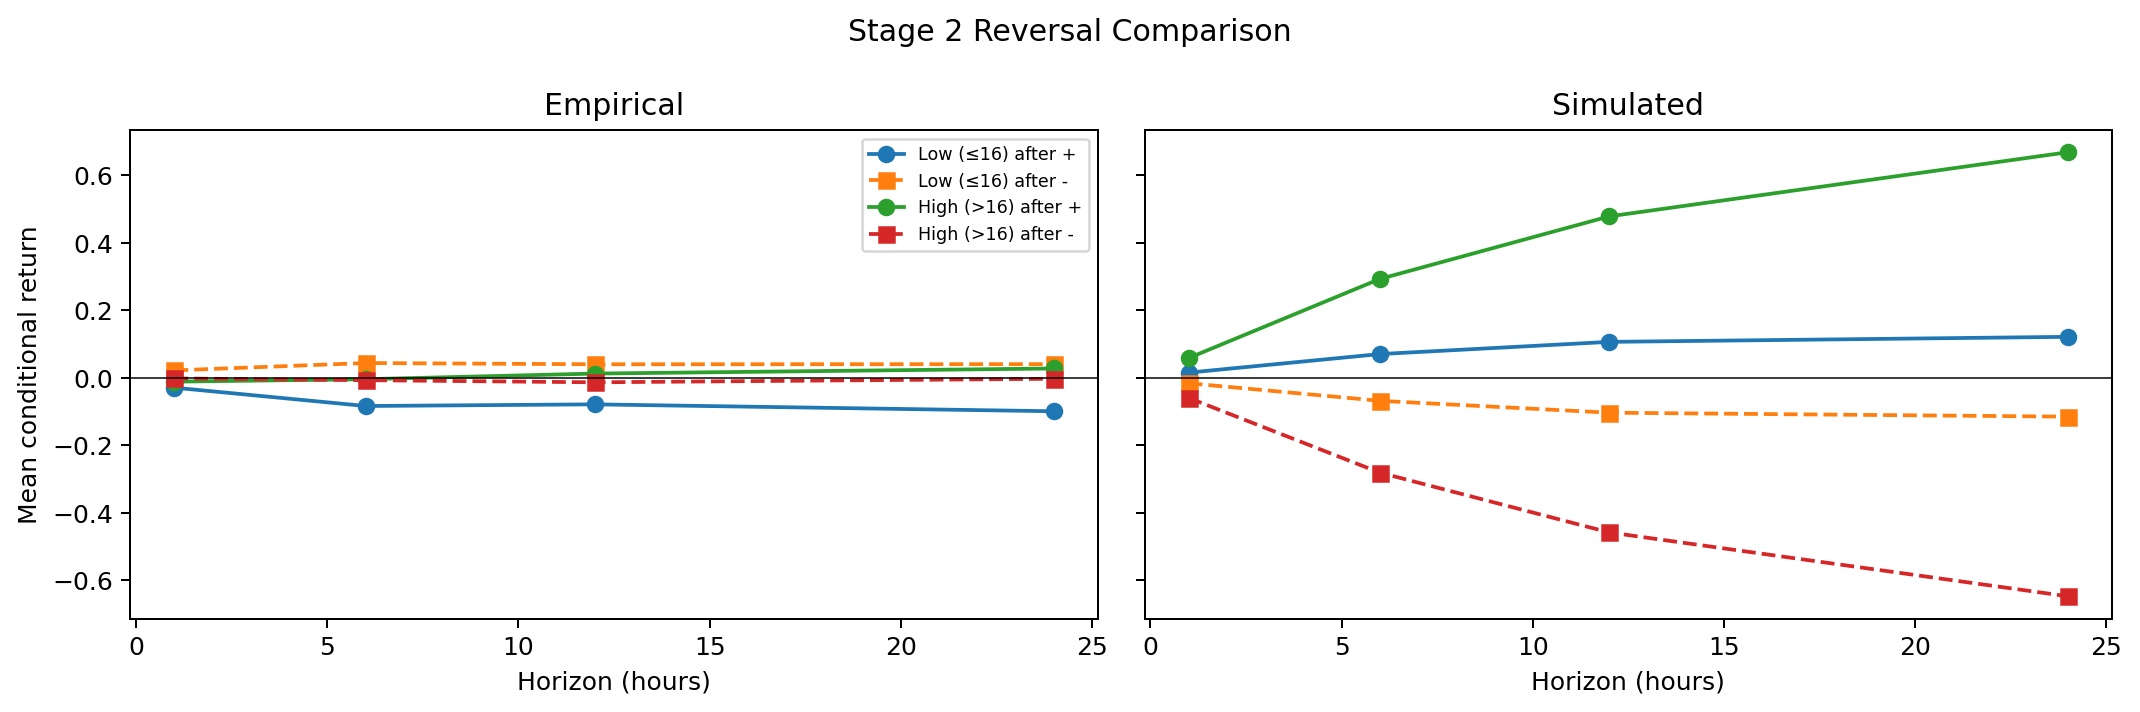

In [113]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_reversal_activity.png'
if img.exists():
    display(Image(filename=str(img)))

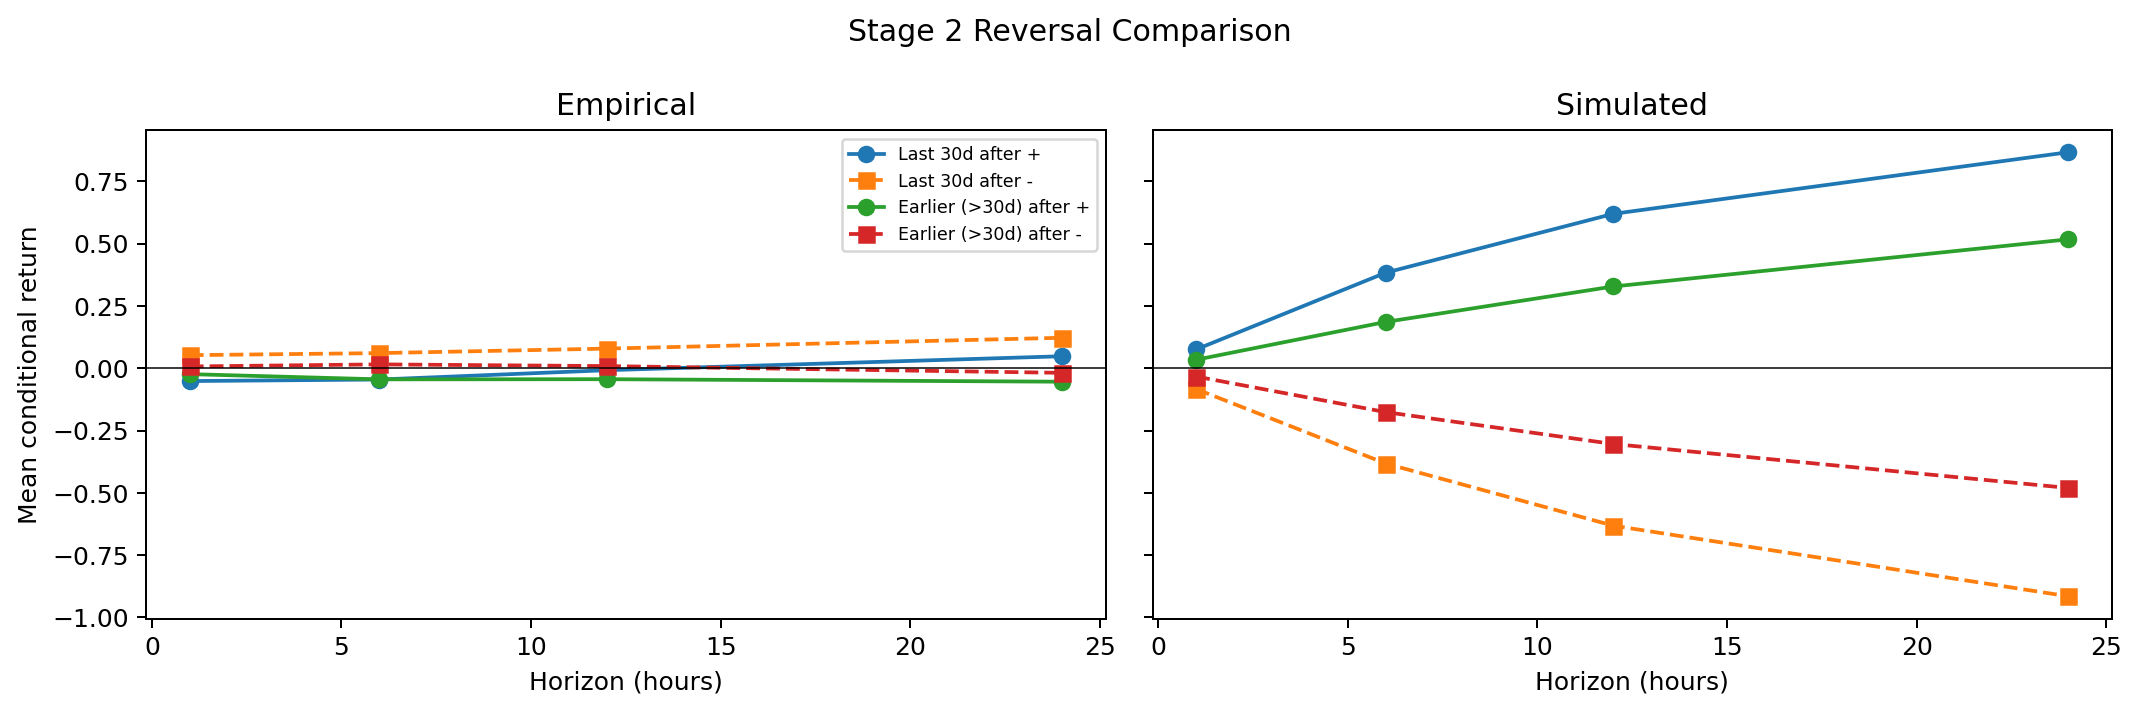

In [114]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage2_reversal_deadline.png'
if img.exists():
    display(Image(filename=str(img)))

## STAGE3

In [115]:
bundle = stage3
if bundle is None:
    display(Markdown('Stage 3 was not run.'))
else:
    display(Markdown(bundle['summary']))
    if bundle['tail_quantiles'] is not None:
        display(bundle['tail_quantiles'])
    if bundle['deadline_summary'] is not None:
        display(bundle['deadline_summary'])
    if bundle['interaction'] is not None:
        display(bundle['interaction'])
    if bundle['quantile_regression_raw'] is not None:
        display(bundle['quantile_regression_raw'])
    if bundle['final_seed_scores'] is not None:
        display(bundle['final_seed_scores'])


# STAGE3 Summary

## Mechanisms Present
- all stage-2 mechanisms
- thin-market transient dislocation state that decays over time
- dislocation shocks only activate in low-activity, large-imbalance states

## Empirical Targets Matched
- late life volatility
- quantile pattern

## Targets Still Missing or Weak
- heavy tails
- volatility clustering
- activity deadline pattern
- low activity reversal

## Calibration Snapshot
- total score: 0.9408
- tail error: 1.2940
- acf error: 0.6699
- deadline error: 0.4020
- ratio error: 0.1963
- monotonic penalty: 0.0000
- interaction error: 0.5080
- interaction pattern penalty: 0.3333
- quantile error: 1.0700
- reversal error: 2.0057

## Next Stage Decision
- justified: no
- reason: No further mechanism stage is planned in the minimal RQ4 build.

,q90,q95,q99,mean_abs_r,std_r
period,,,,,
Overall,0.053365,0.086385,0.167308,0.016572,0.038768
Earlier,0.048657,0.079170,0.148456,0.015055,0.034793
Last 30d,0.089892,0.143450,0.246078,0.028134,0.061086


,n,mean_abs_r,std_r,kurtosis,skewness,acf1_abs_r,mean_trade_rate
period,,,,,,,
Earlier,78720,0.015055,0.034793,16.074173,-0.203489,0.326296,92.182043
Last 30d,10327,0.028134,0.061086,12.736165,0.204098,0.350688,123.750896


mean_abs_r     std_r      n
ttr_phase activity_bin                             
Earlier   Low             0.010323  0.030012  28914
          Mid             0.016924  0.038648  26480
          High            0.018800  0.035682  23326
Last 30d  Low             0.018684  0.053955   1207
          Mid             0.021912  0.053485   3057
          High            0.033152  0.065822   6063

,trade_rate_coef,trade_rate_p,ttr_coef,ttr_p,pseudo_r2
quantile,,,,,
0.50,0.000028,0.000000e+00,0.000001,5.110792e-15,0.007686
0.75,0.000198,0.000000e+00,-0.000016,1.647054e-29,0.044358
0.90,0.000286,6.995691e-222,-0.000116,1.052700e-120,0.052096
0.95,0.000190,1.398955e-31,-0.000206,5.385962e-109,0.046745


,seed,score,tail_error,acf_error,deadline_error,ratio_error,monotonic_penalty,total_score,interaction_error,interaction_pattern_penalty,quantile_error,reversal_error
0,401,0.962300,1.296194,0.725396,0.418113,0.306878,0.0,0.962300,0.511340,0.333333,1.069875,2.044363
1,402,0.940824,1.293962,0.669928,0.401958,0.196287,0.0,0.940824,0.508036,0.333333,1.069993,2.005681


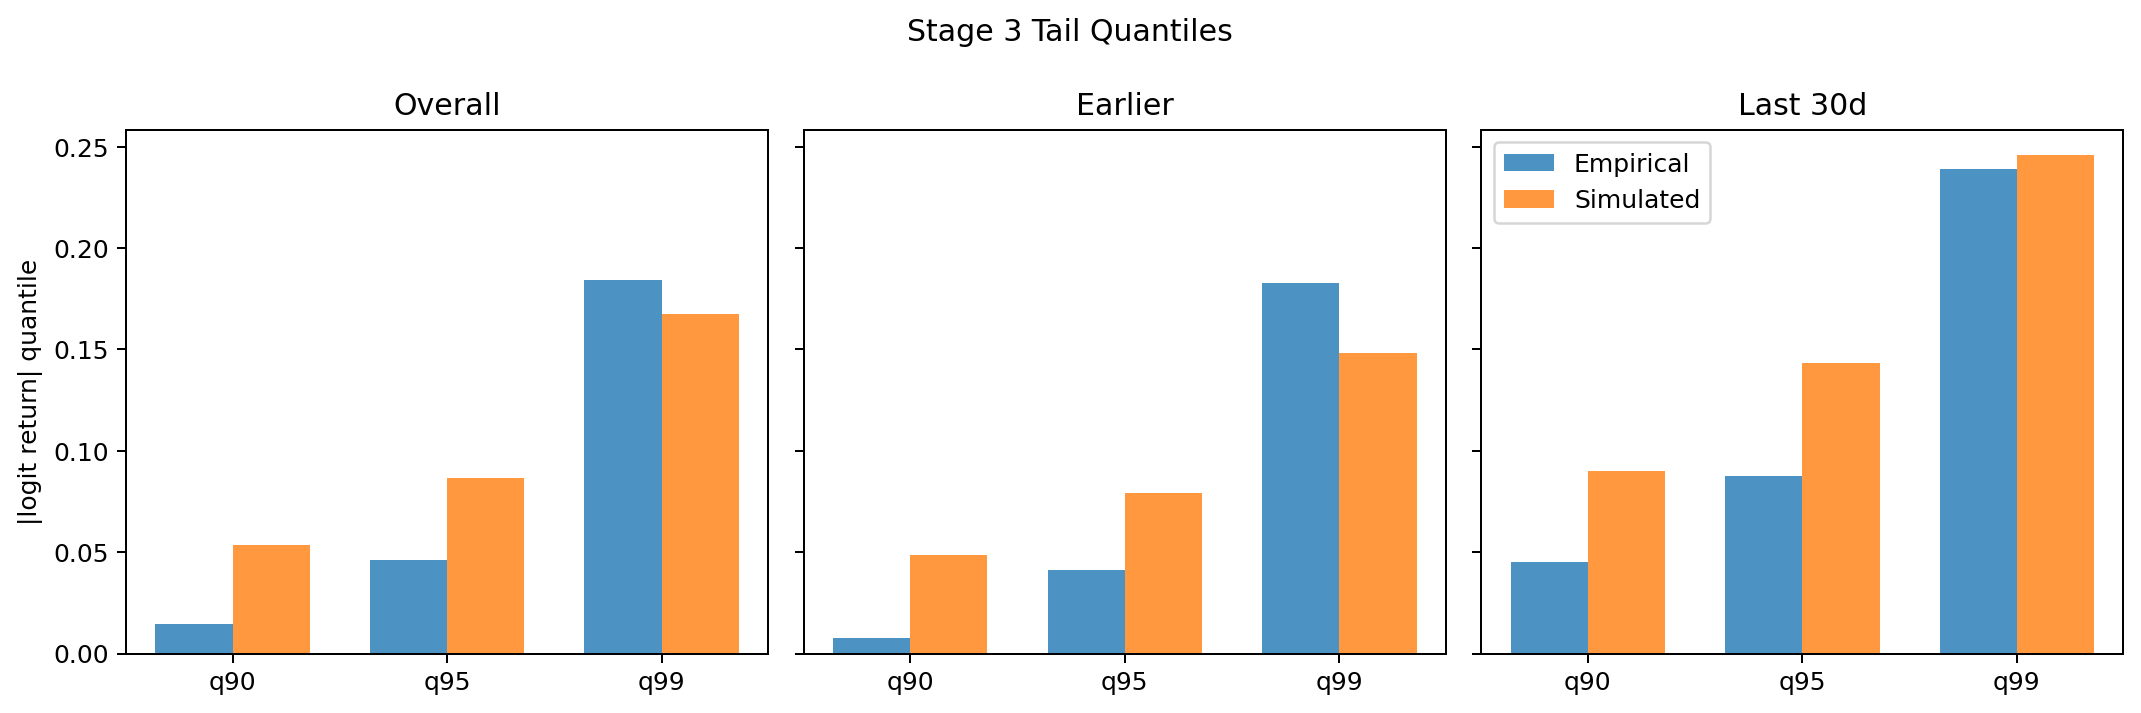

In [116]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_tail_quantiles.png'
if img.exists():
    display(Image(filename=str(img)))

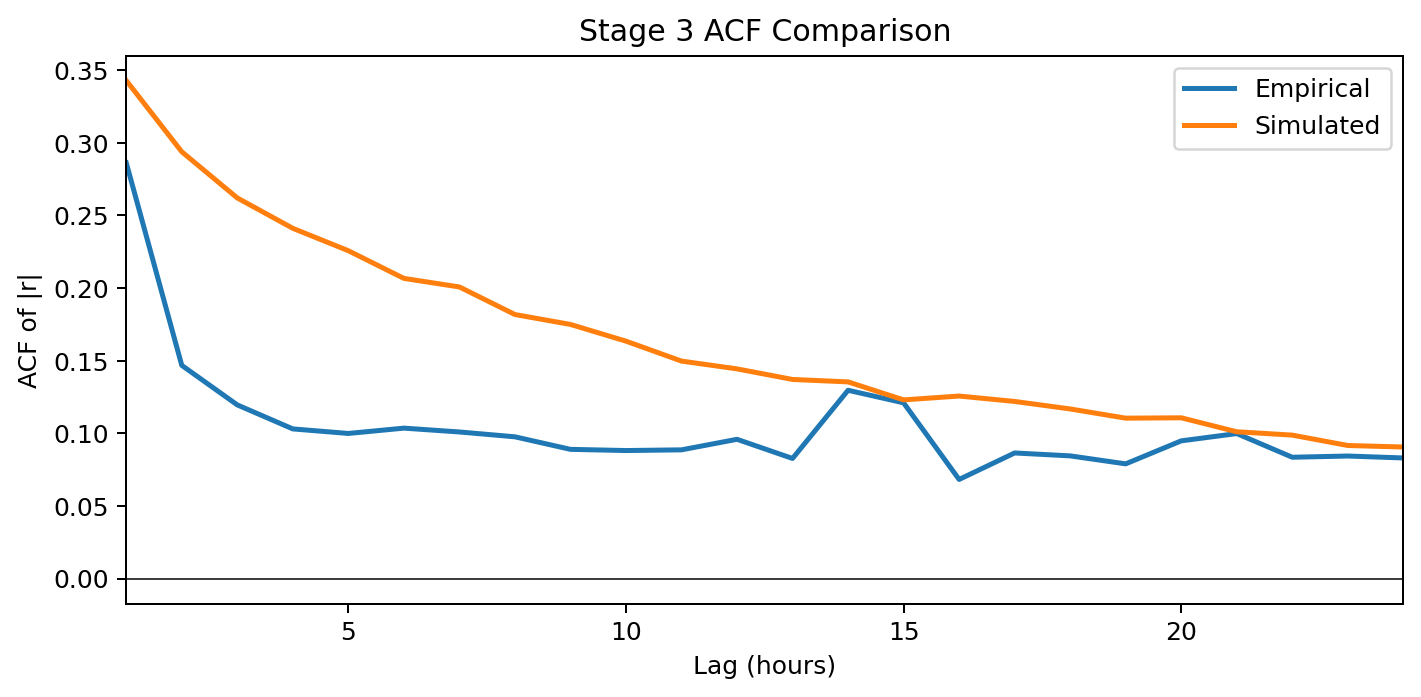

In [117]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_acf.png'
if img.exists():
    display(Image(filename=str(img)))

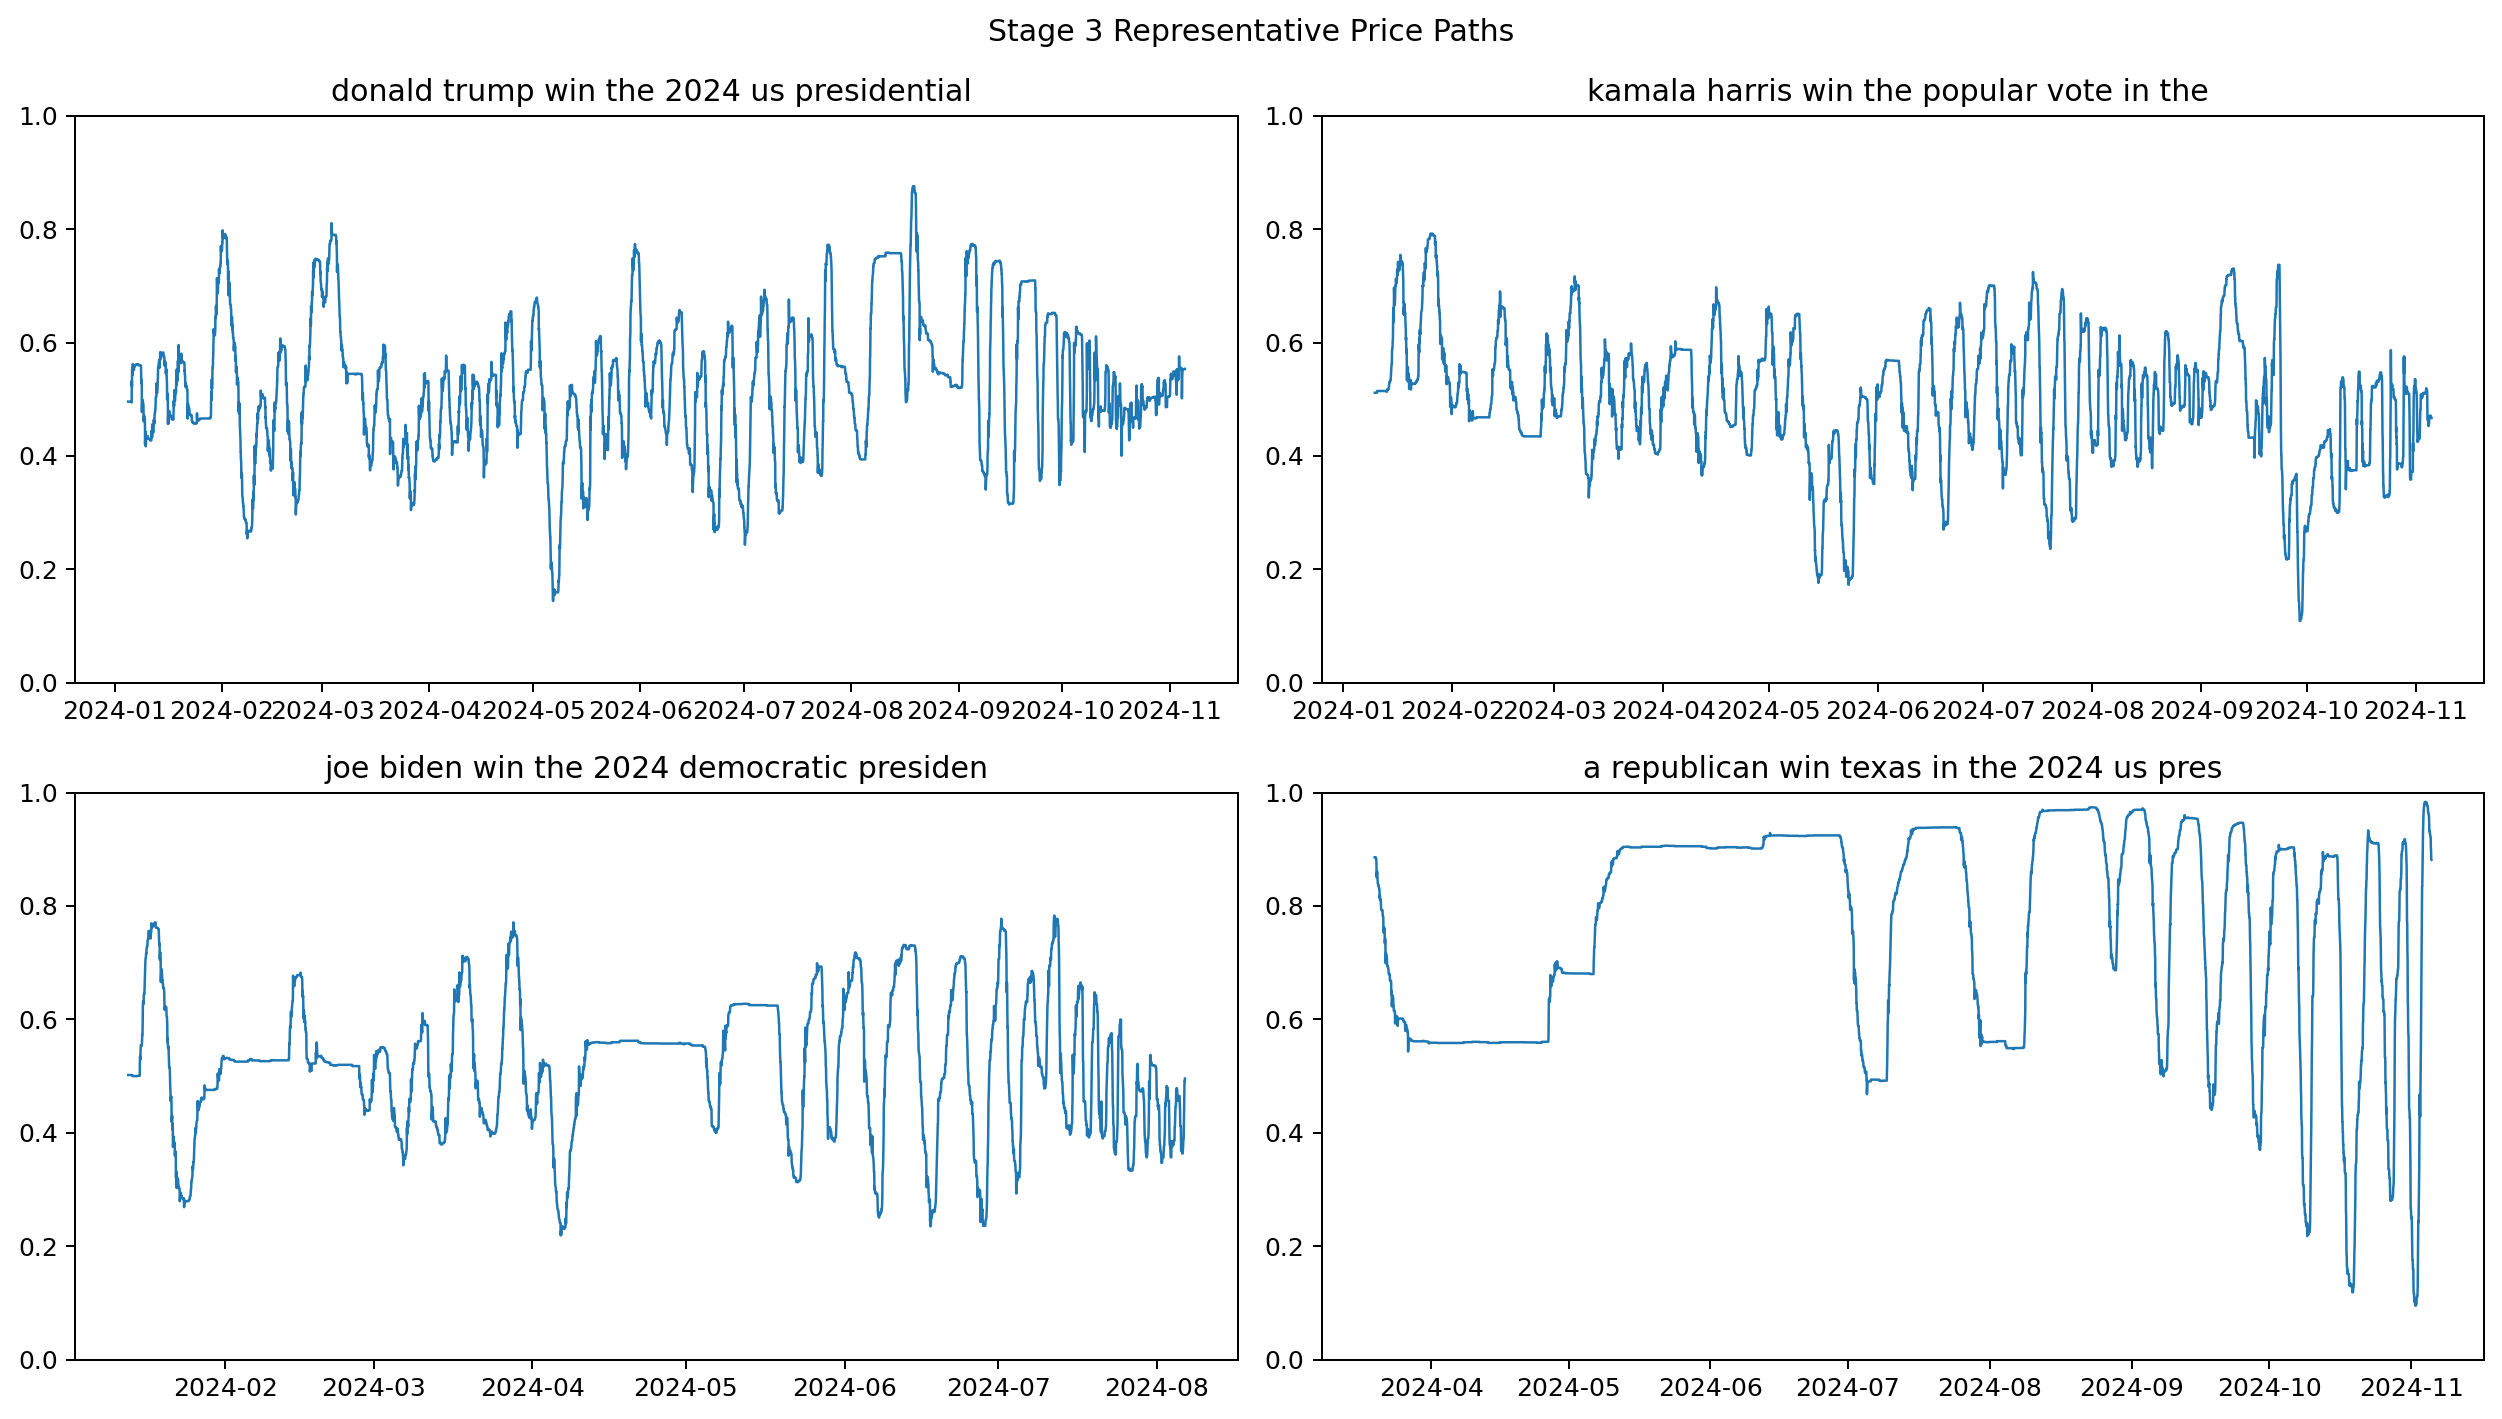

In [118]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_price_paths.png'
if img.exists():
    display(Image(filename=str(img)))

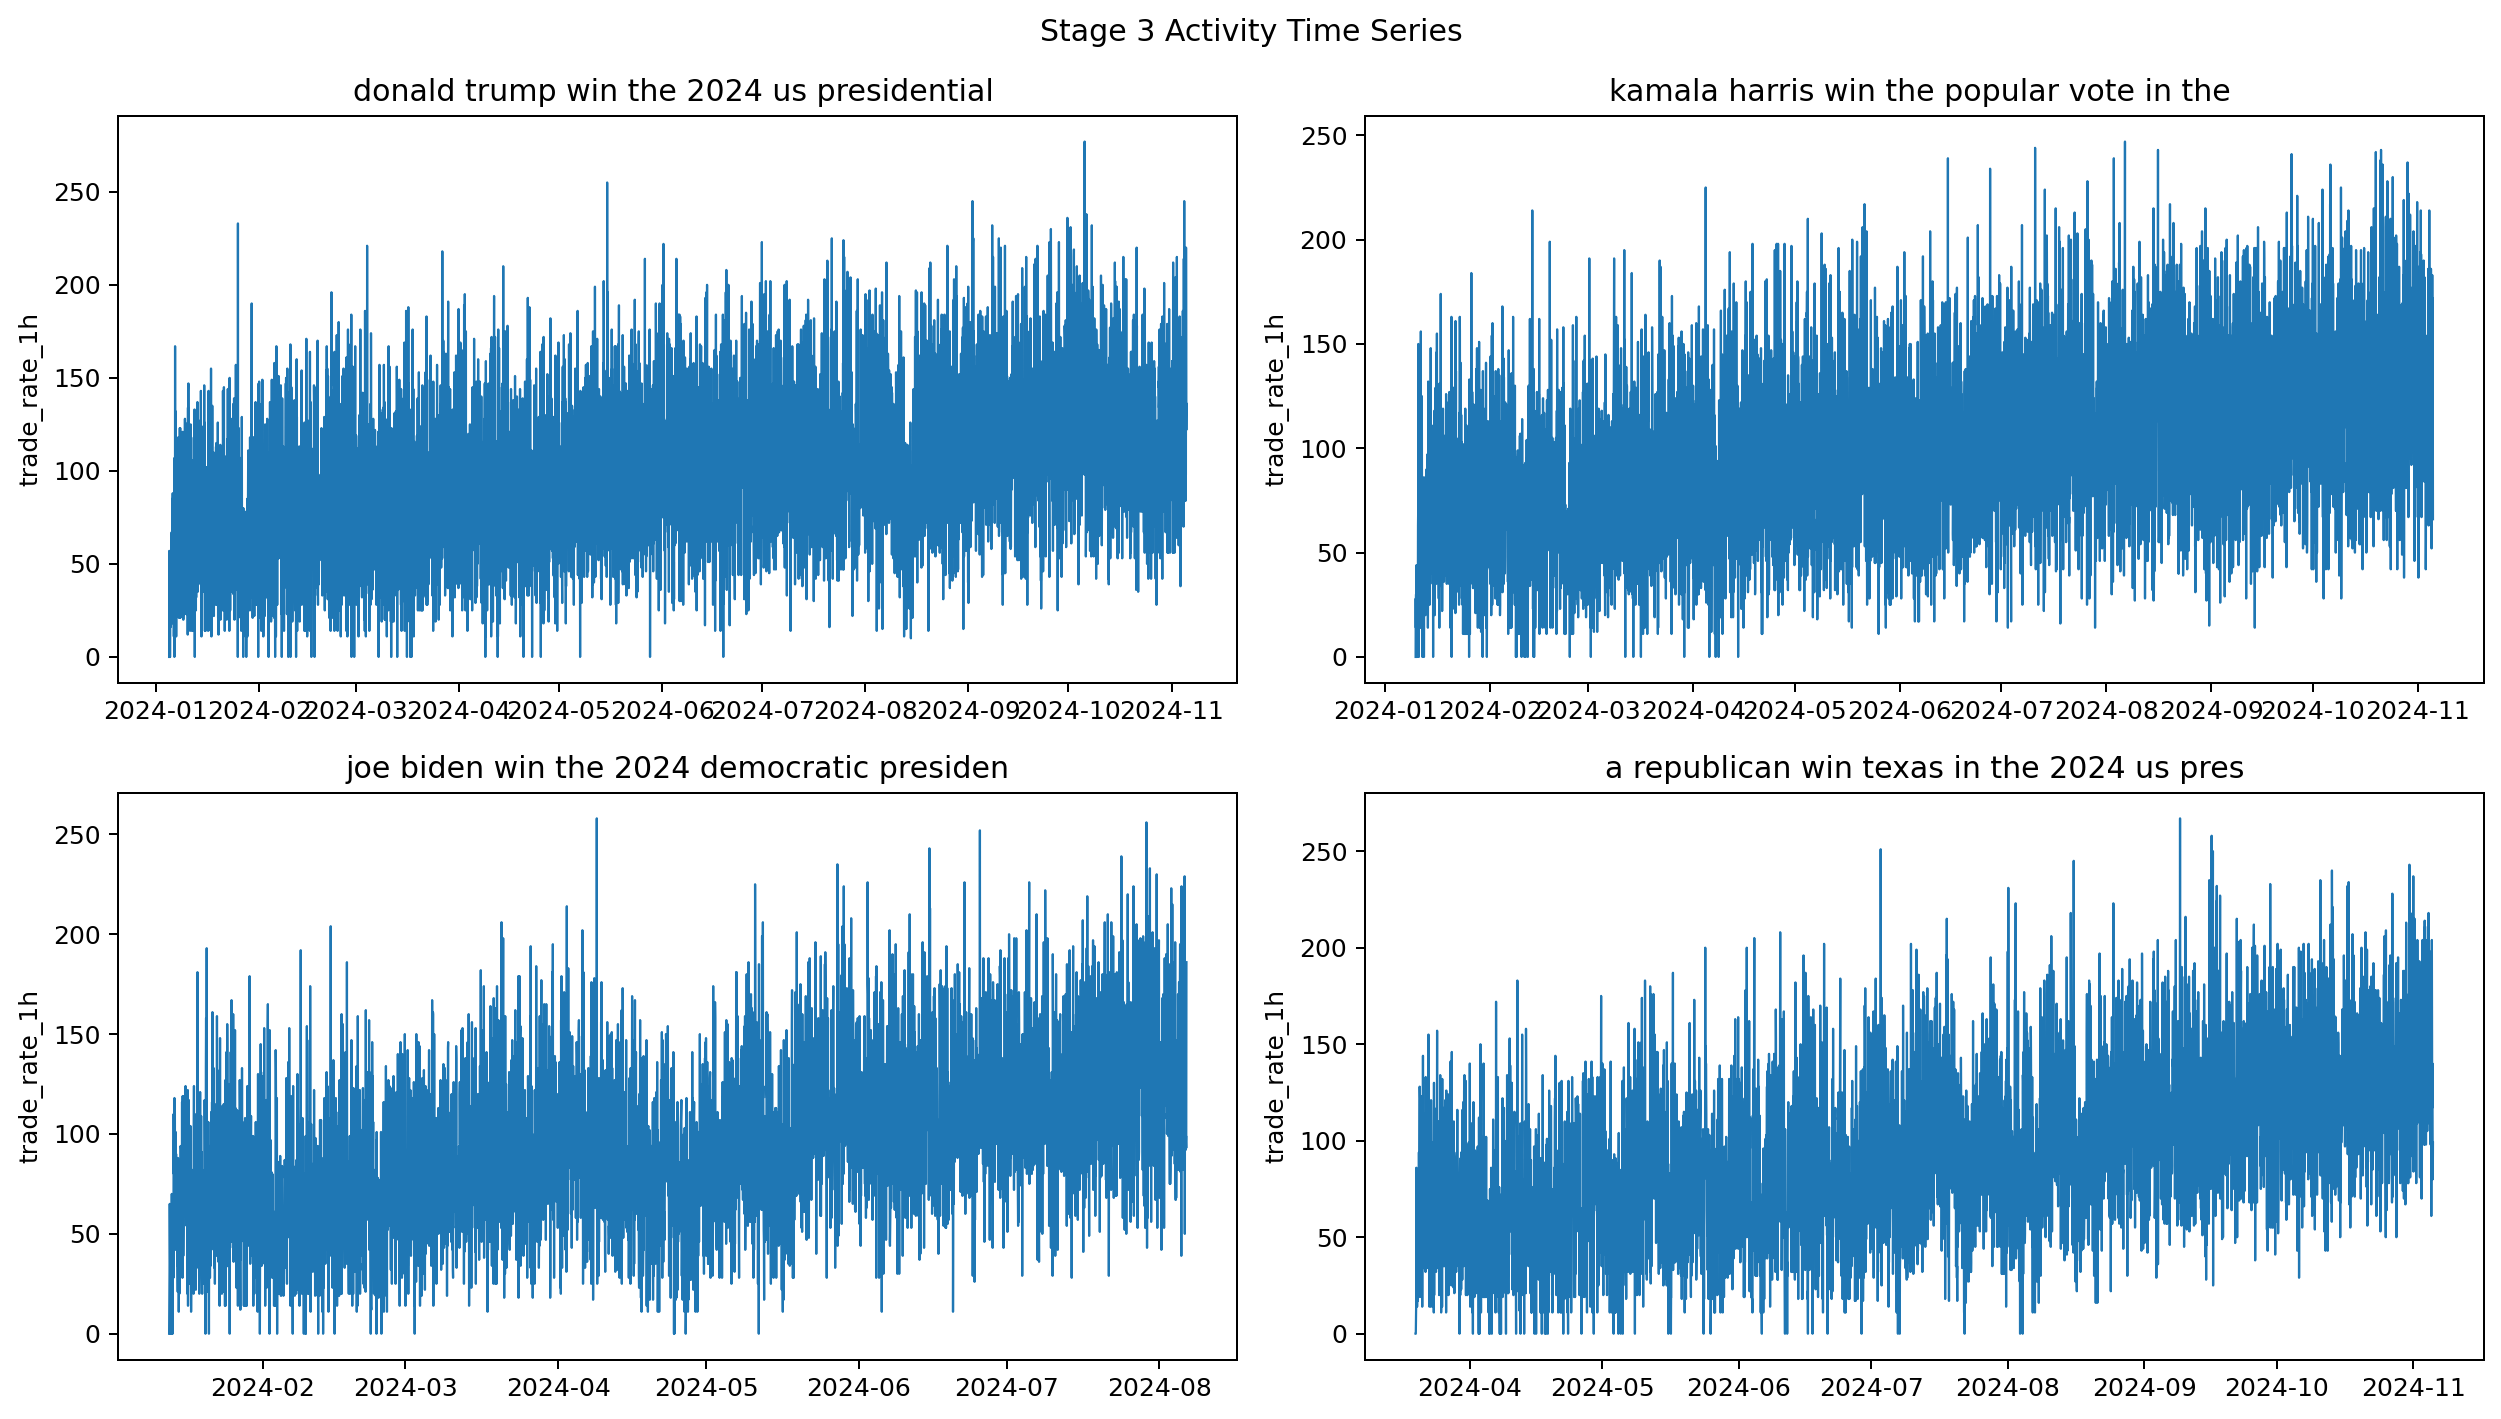

In [119]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_trade_rate.png'
if img.exists():
    display(Image(filename=str(img)))

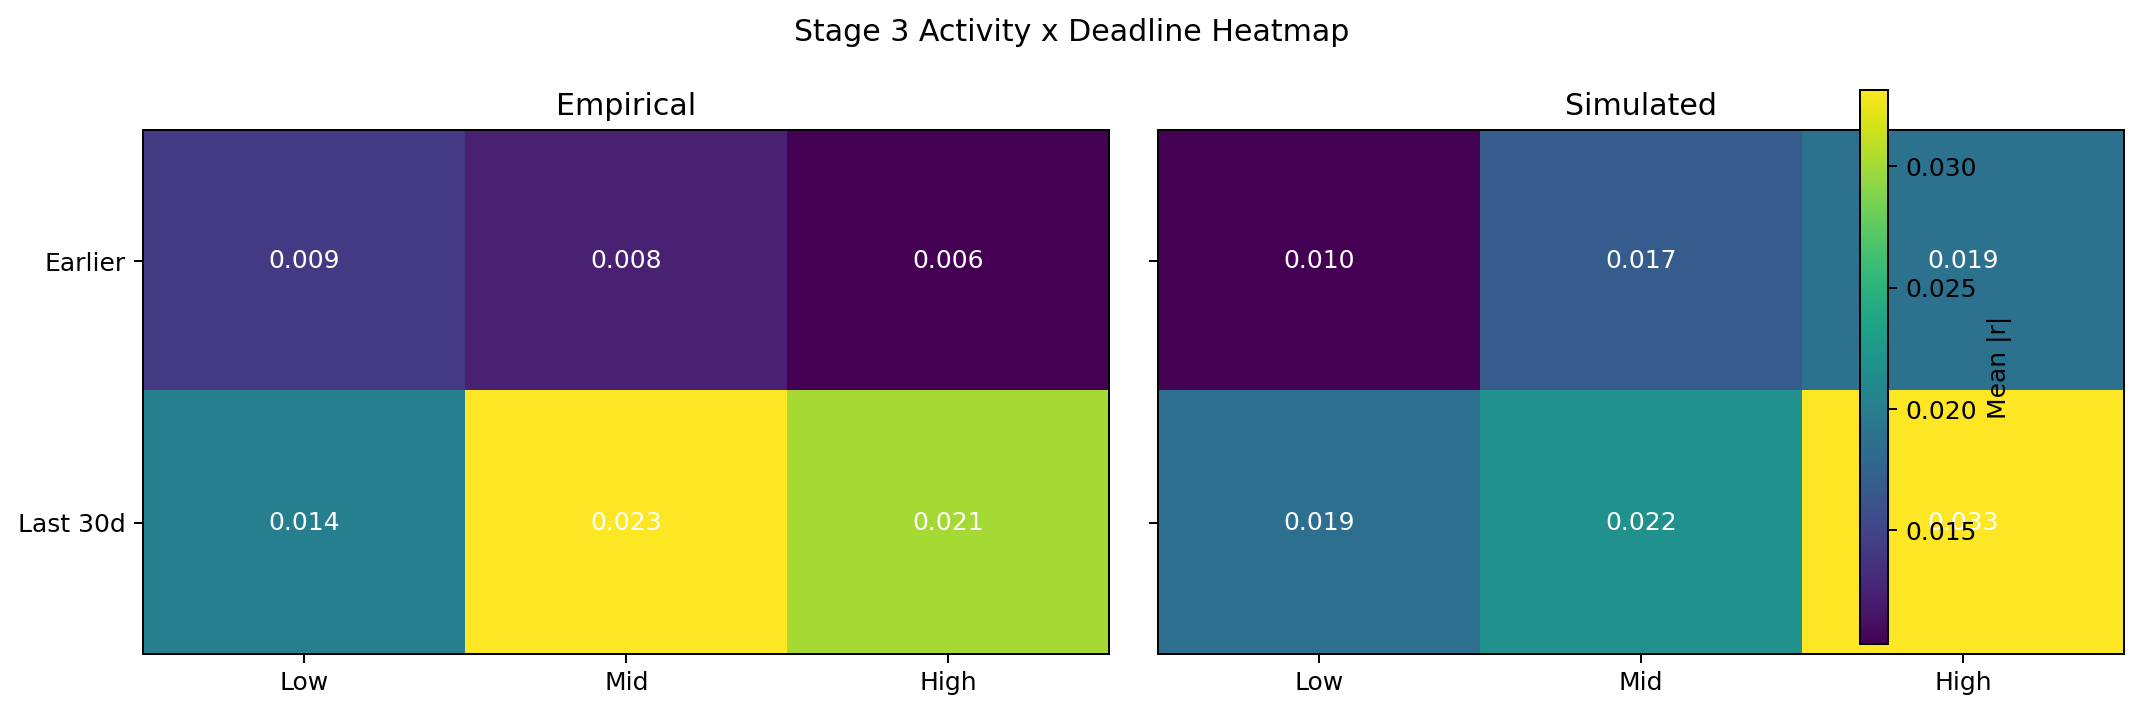

In [120]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_activity_heatmap.png'
if img.exists():
    display(Image(filename=str(img)))

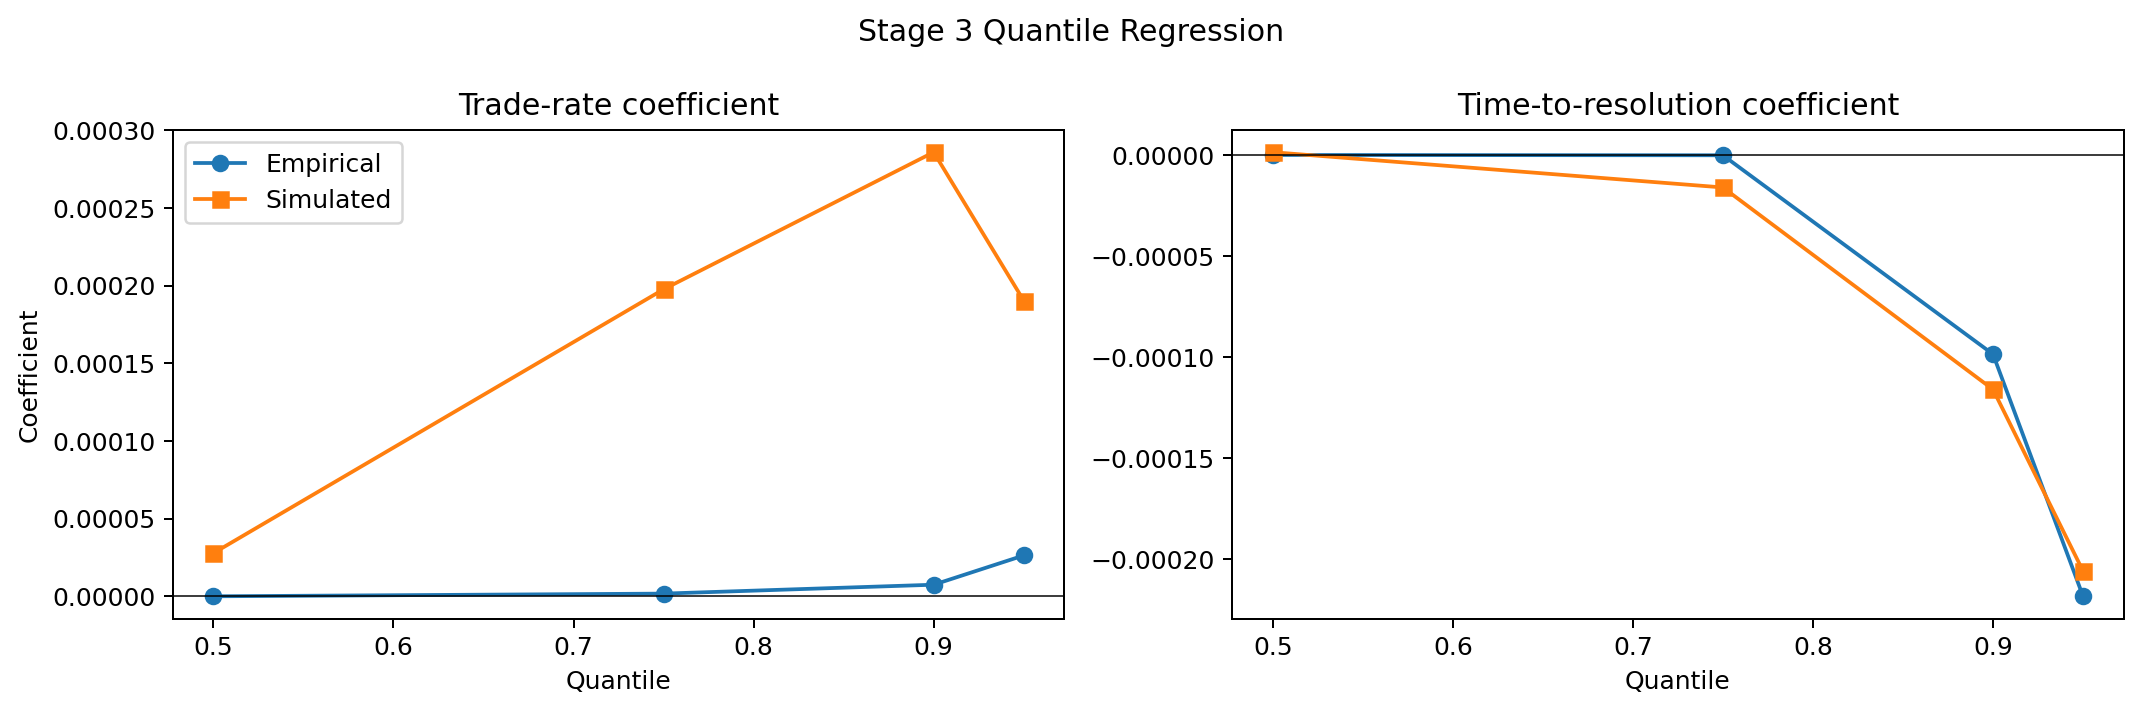

In [121]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_quantile_regression.png'
if img.exists():
    display(Image(filename=str(img)))

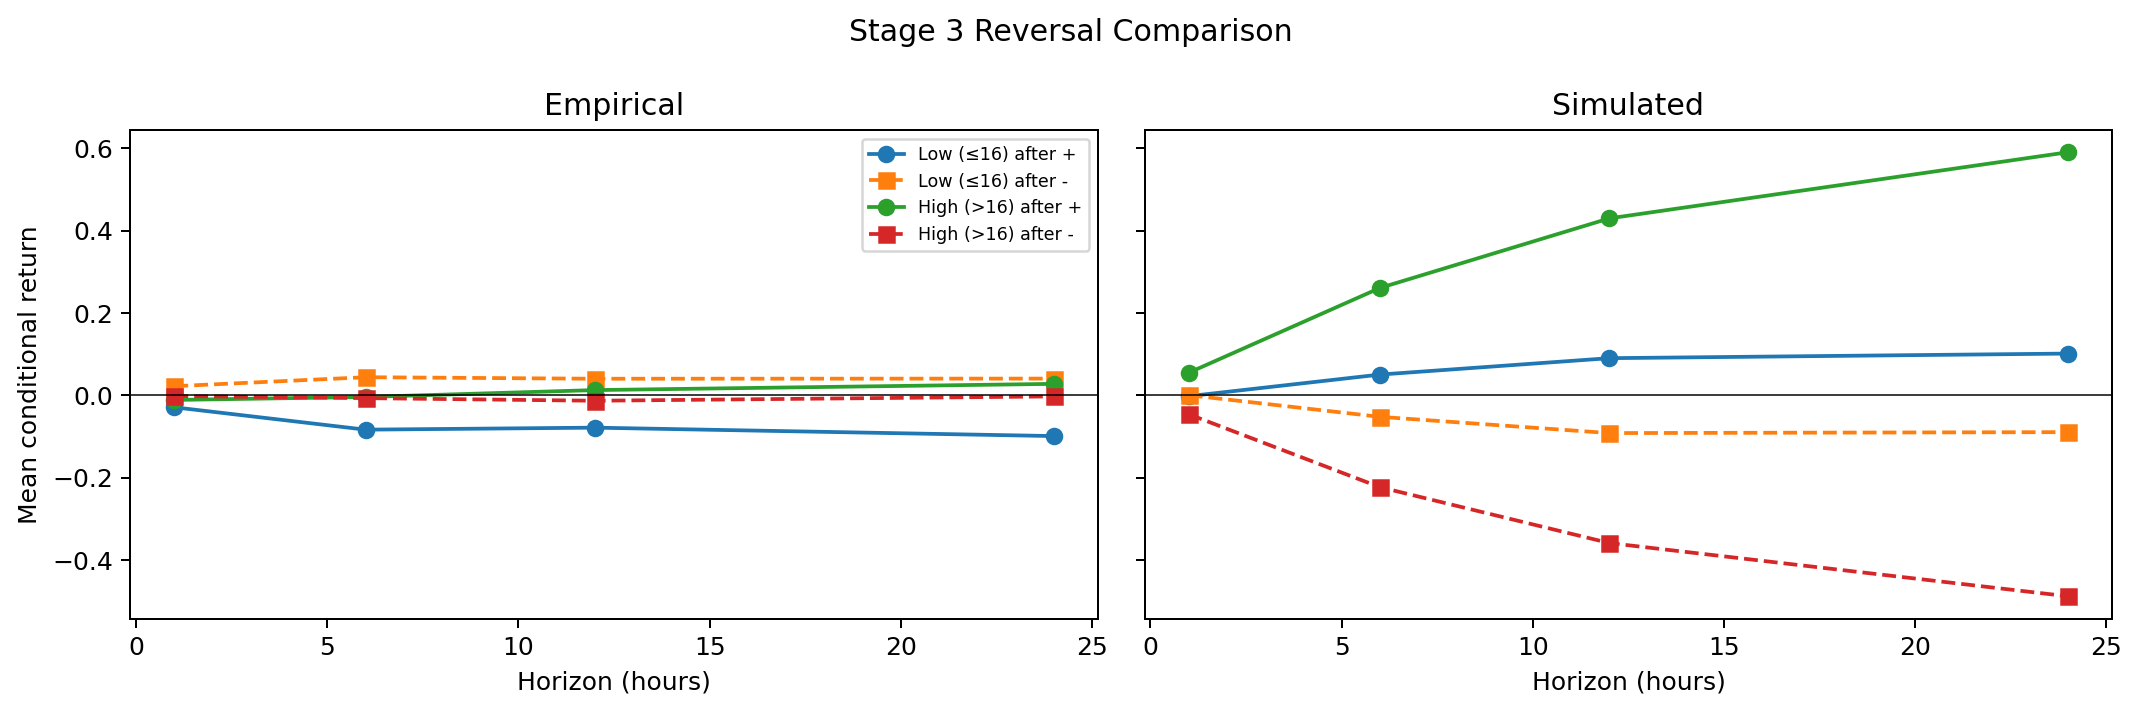

In [122]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_reversal_activity.png'
if img.exists():
    display(Image(filename=str(img)))

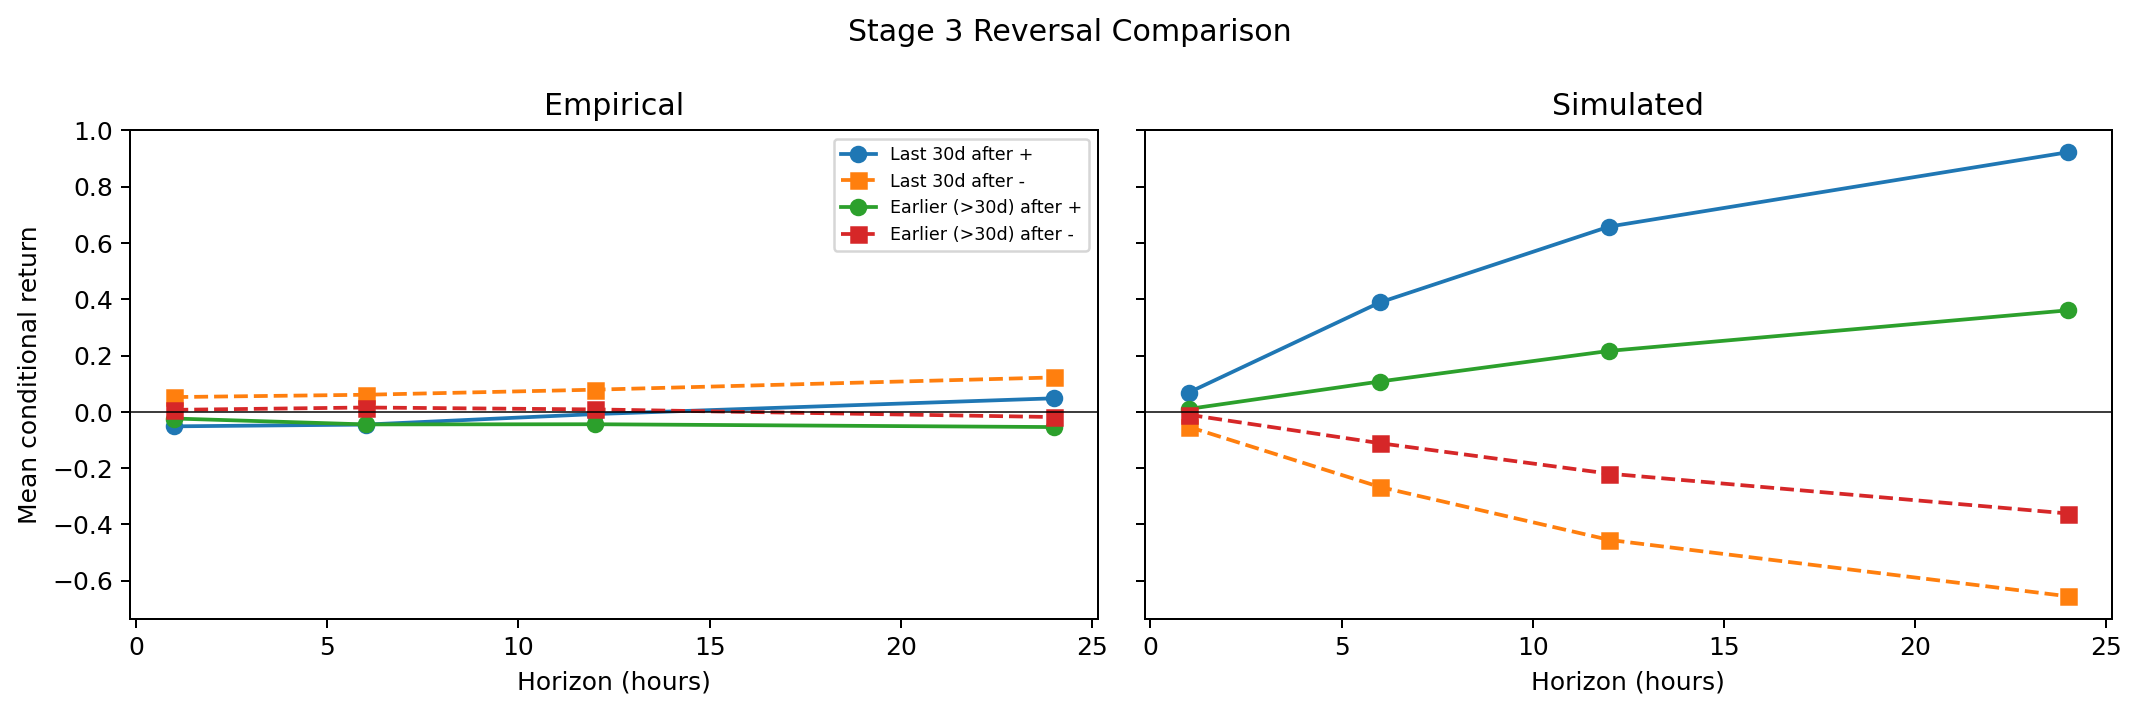

In [123]:
img = Path.cwd().parent / 'plots' / f'{ABM_PLOT_PREFIX}_stage3_reversal_deadline.png'
if img.exists():
    display(Image(filename=str(img)))

## Minimal Mechanism Answer

In [124]:
pipeline_summary

stage1_score                0.701361
stage2_score                0.765029
stage3_ran                      True
stage3_score                0.940824
minimal_mechanism_answer      stage2
dtype: object